# Capstone EDA — Agentic AI Platform for Remote Patient Monitoring

**Objective.** Establish exactly what the three available datasets contain, and determine whether they
support the eleven project deliverables. Where they do not, quantify the gap precisely enough to decide
what must be sourced or synthesised.

**Datasets on disk**

| # | Dataset | Role in the platform |
|---|---|---|
| 1 | MIMIC-IV Clinical Database Demo v2.2 | Hospital EHR, ICU monitoring, labs, medications, outcomes |
| 2 | MIMIC-IV-ECG Diagnostic Demo v0.1 | Diagnostic waveform modality |
| 3 | Wearable dataset — induced stress & structured exercise v1.0.1 | Wearable/IoT signal modality |

**The six declared input sources** we must account for: real-time ICU monitors, wearable health devices,
hospital EHR systems, laboratory results, clinical notes, discharge summaries.

**How to read this notebook.** Each section ends with an *Interpretation* block stating what the numbers
mean for the build. The final section consolidates these into a coverage verdict and a gap register.

---

## 0. Setup

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# ---- Project paths -------------------------------------------------------
ROOT     = Path("/Users/ritik/Documents/Captsone ISB AMPBA")
MIMIC    = ROOT / "mimic-iv-clinical-database-demo-2.2"
ECG      = ROOT / "mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1"
WEAR     = ROOT / "wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1"
FIGDIR   = ROOT / "eda_figures"
FIGDIR.mkdir(exist_ok=True)

for p in (MIMIC, ECG, WEAR):
    assert p.exists(), f"Missing dataset: {p}"
print("All three dataset folders found.")

# ---- Plot style ----------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "font.size": 10,
})

# Semantic colours used consistently throughout
OK, WARN, BAD, NEUTRAL, ACCENT = "#1baf7a", "#eda100", "#e34948", "#888780", "#2a78d6"

def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight")
    return fig

All three dataset folders found.


In [2]:
def read_mimic(module, table):
    '''Read a MIMIC-IV demo table. Prefers the .csv.gz original over any loose .csv copy.'''
    gz = MIMIC / module / f"{table}.csv.gz"
    if gz.exists():
        return pd.read_csv(gz, low_memory=False)
    return pd.read_csv(MIMIC / module / f"{table}.csv", low_memory=False)

def pct(n, d):
    return 0.0 if d == 0 else round(100 * n / d, 1)

---
## 1. Dataset inventory

Before any analysis, establish the physical scale of what we hold: which tables exist, how many rows,
and which of the six declared input sources each one speaks to.

In [3]:
inventory = []
for module in ["hosp", "icu"]:
    for f in sorted((MIMIC / module).glob("*.csv.gz")):
        name = f.name.replace(".csv.gz", "")
        df = pd.read_csv(f, low_memory=False)
        inventory.append({
            "module": module, "table": name,
            "rows": len(df), "cols": df.shape[1],
            "file_mb": round(f.stat().st_size / 1e6, 2),
        })
inv = pd.DataFrame(inventory).sort_values("rows", ascending=False).reset_index(drop=True)
print(f"MIMIC-IV demo: {len(inv)} tables, {inv.rows.sum():,} total rows\n")
inv

MIMIC-IV demo: 31 tables, 1,398,500 total rows



,module,table,rows,cols,file_mb
0,icu,chartevents,668862,11,5.55
1,hosp,d_icd_diagnoses,109775,3,1.81
2,hosp,labevents,107727,16,1.96
3,hosp,d_hcpcs,89200,4,0.51
4,hosp,d_icd_procedures,85257,3,1.08
5,hosp,emar_detail,72018,33,0.69
6,hosp,poe,45154,12,0.61
7,hosp,provider,40508,1,0.15
8,hosp,emar,35835,12,0.73
9,icu,ingredientevents,25728,17,0.60


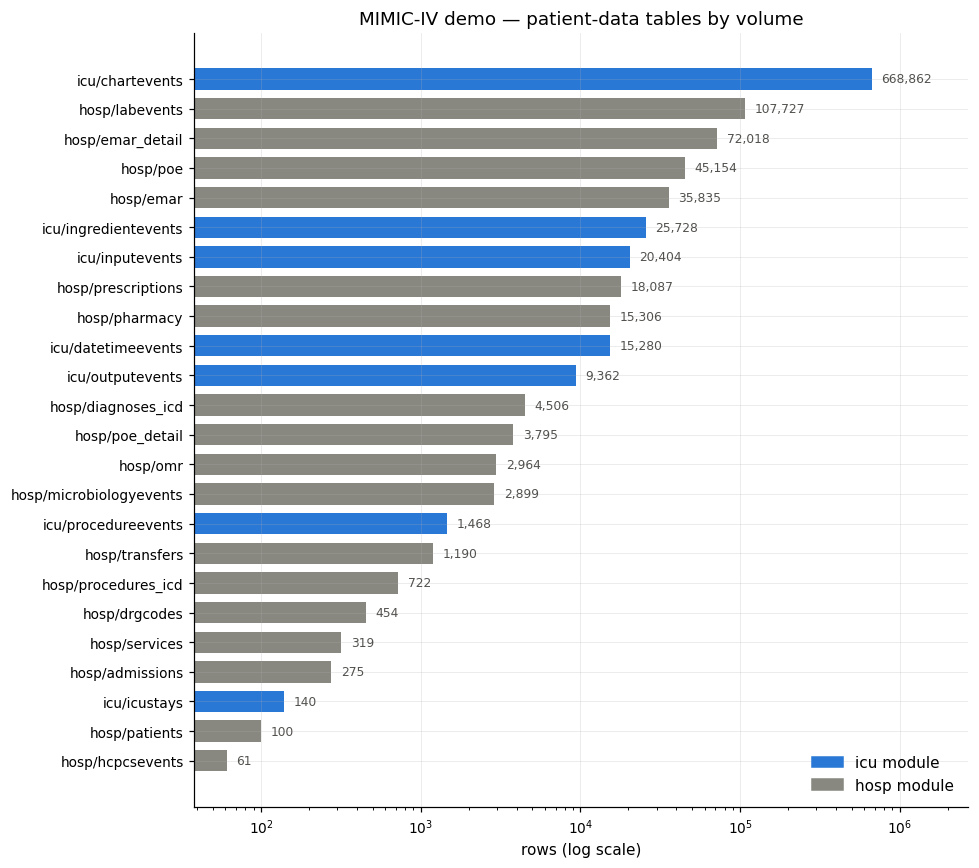

In [4]:
# Which tables carry data volume worth modelling? (dictionary tables excluded - they are static lookups)
DICT_TABLES = {"d_hcpcs", "d_icd_diagnoses", "d_icd_procedures", "d_labitems", "d_items",
               "provider", "caregiver"}
data_tables = inv[~inv.table.isin(DICT_TABLES)].sort_values("rows")

fig, ax = plt.subplots(figsize=(9, 8))
colors = [ACCENT if m == "icu" else NEUTRAL for m in data_tables.module]
ax.barh(data_tables.module + "/" + data_tables.table, data_tables.rows, color=colors, height=0.72)
ax.set_xscale("log")
ax.set_xlabel("rows (log scale)")
ax.set_title("MIMIC-IV demo — patient-data tables by volume")
for y, v in enumerate(data_tables.rows):
    ax.text(v * 1.15, y, f"{v:,}", va="center", fontsize=8, color="#52514e")
ax.set_xlim(right=data_tables.rows.max() * 4)
handles = [plt.Rectangle((0,0),1,1, color=ACCENT), plt.Rectangle((0,0),1,1, color=NEUTRAL)]
ax.legend(handles, ["icu module", "hosp module"], loc="lower right")
save(fig, "01_table_inventory"); plt.show()

**Interpretation.** `chartevents` (669k rows) dominates by two orders of magnitude and is the single most
important table for this project — it is the ICU monitoring stream. `labevents` (108k) is second. Together
they carry the time-series signal that every early-warning model will consume. Everything else is context:
demographics, orders, diagnoses.

Note the absence of any `note` module. This is confirmed explicitly in the dataset README and is the first
gap we will have to close.

---
## 2. Cohort characterisation

Who are these 100 patients? Cohort composition determines whether the demo can support the ICU and
post-discharge scenarios the platform targets.

In [5]:
patients   = read_mimic("hosp", "patients")
admissions = read_mimic("hosp", "admissions")
icustays   = read_mimic("icu", "icustays")
transfers  = read_mimic("hosp", "transfers")

for c in ["admittime", "dischtime", "deathtime", "edregtime", "edouttime"]:
    admissions[c] = pd.to_datetime(admissions[c])
for c in ["intime", "outtime"]:
    icustays[c] = pd.to_datetime(icustays[c])

admissions["los_hosp_days"] = (admissions.dischtime - admissions.admittime).dt.total_seconds() / 86400

print(f"Patients          : {patients.subject_id.nunique()}")
print(f"Hospital admissions: {len(admissions)}  ({admissions.groupby('subject_id').size().mean():.2f} per patient)")
print(f"ICU stays          : {len(icustays)}  across {icustays.subject_id.nunique()} patients")
print(f"ED encounters      : {admissions.edregtime.notna().sum()} admissions arrived via ED")
print(f"Deaths recorded    : {patients.dod.notna().sum()} patients have a date of death")

Patients          : 100
Hospital admissions: 275  (2.75 per patient)
ICU stays          : 140  across 100 patients
ED encounters      : 182 admissions arrived via ED
Deaths recorded    : 31 patients have a date of death


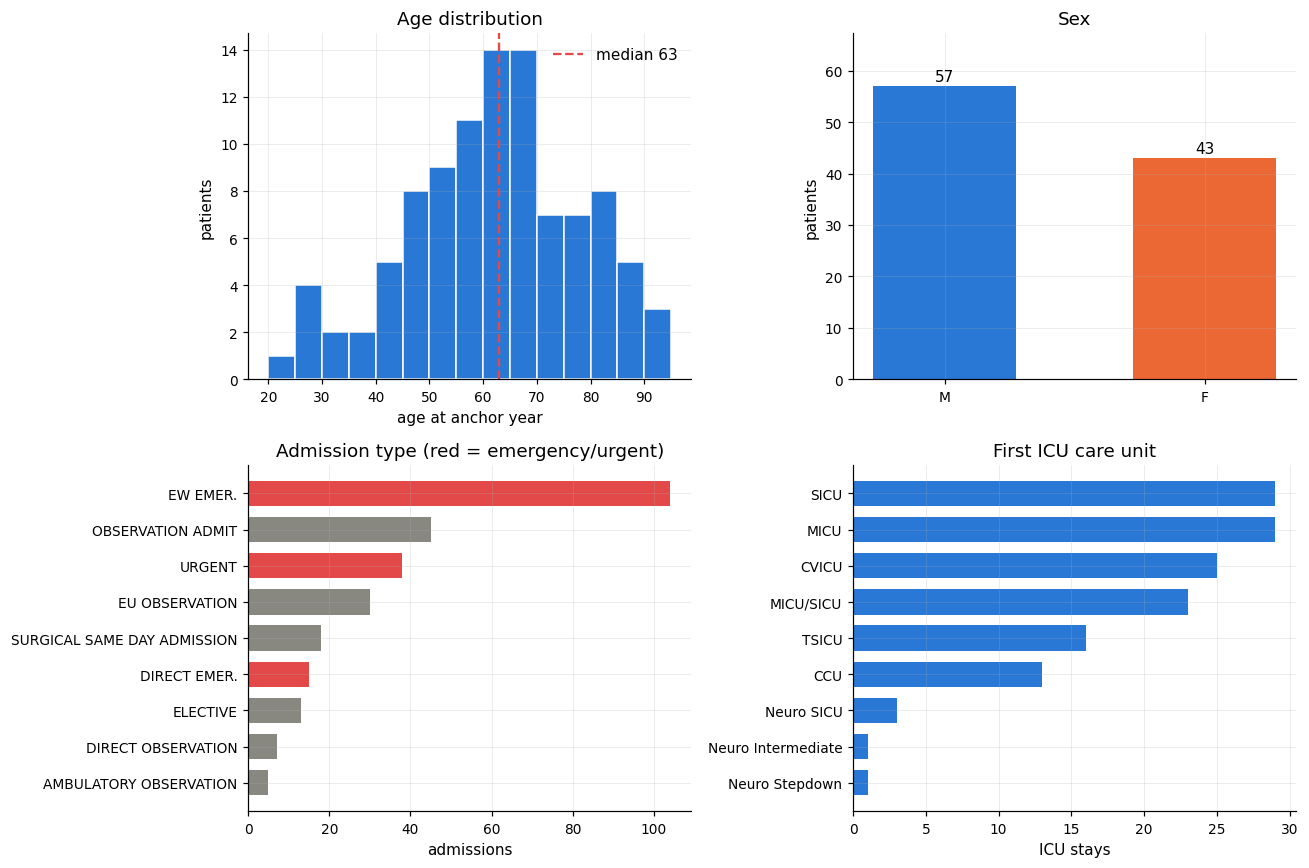

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Age
ax = axes[0, 0]
ax.hist(patients.anchor_age, bins=np.arange(20, 100, 5), color=ACCENT, edgecolor="white")
ax.axvline(patients.anchor_age.median(), color=BAD, ls="--", lw=1.5,
           label=f"median {patients.anchor_age.median():.0f}")
ax.set_xlabel("age at anchor year"); ax.set_ylabel("patients")
ax.set_title("Age distribution"); ax.legend()

# Gender
ax = axes[0, 1]
g = patients.gender.value_counts()
ax.bar(g.index, g.values, color=[ACCENT, "#eb6834"], width=0.55)
for i, v in enumerate(g.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=10)
ax.set_ylabel("patients"); ax.set_title("Sex"); ax.set_ylim(0, g.max() * 1.18)

# Admission type
ax = axes[1, 0]
at = admissions.admission_type.value_counts().sort_values()
is_emergency = at.index.str.contains("EMER|URGENT", case=False)
ax.barh(at.index, at.values, color=[BAD if e else NEUTRAL for e in is_emergency], height=0.7)
ax.set_xlabel("admissions"); ax.set_title("Admission type (red = emergency/urgent)")

# ICU care unit
ax = axes[1, 1]
cu = icustays.first_careunit.value_counts().sort_values()
short = [c.split("(")[-1].rstrip(")") if "(" in c else c for c in cu.index]
ax.barh(short, cu.values, color=ACCENT, height=0.7)
ax.set_xlabel("ICU stays"); ax.set_title("First ICU care unit")

save(fig, "02_cohort"); plt.show()

**Interpretation.** This is a genuinely acute cohort, which is what the project needs. Median age 63,
and emergency or urgent admissions dominate. Every one of the 100 patients has at least one ICU stay
(140 stays total), spread across seven distinct ICU types — medical, surgical, cardiac, trauma and
neuro. The care-unit diversity matters: an early-warning model tuned only to, say, cardiac patients
would not generalise, and here we have a mix.

182 of 275 admissions arrived through the Emergency Department, so the ED-to-ICU deterioration pathway
— a core scenario for the alerting engine — is represented in the data.

---
## 3. Outcomes — the supervised learning targets

Every predictive deliverable needs labels. This section counts them. For a 100-patient demo the counts
are the binding constraint on what can honestly be claimed, so we quantify them carefully rather than
discovering the problem during model training.

In [7]:
# --- In-hospital mortality ---
deaths = int(admissions.hospital_expire_flag.sum())
print(f"In-hospital deaths      : {deaths} / {len(admissions)} admissions ({pct(deaths, len(admissions))}%)")

icu_out = icustays.merge(admissions[["hadm_id", "hospital_expire_flag"]], on="hadm_id", how="left")
icu_deaths = int(icu_out.hospital_expire_flag.sum())
print(f"ICU stays ending in death: {icu_deaths} / {len(icustays)} ({pct(icu_deaths, len(icustays))}%)")

# --- Readmission ---
a = admissions.sort_values(["subject_id", "admittime"]).copy()
a["next_admittime"] = a.groupby("subject_id").admittime.shift(-1)
a["days_to_next"]   = (a.next_admittime - a.dischtime).dt.total_seconds() / 86400
alive = a[a.hospital_expire_flag == 0]          # index admission must end in a live discharge

readmit = {}
for w in (30, 60, 90):
    readmit[w] = int((alive.days_to_next <= w).sum())
    print(f"{w:>3}-day readmissions     : {readmit[w]} / {len(alive)} alive discharges ({pct(readmit[w], len(alive))}%)")

print(f"\nPatients with >1 admission: {(admissions.groupby('subject_id').size() > 1).sum()} / 100")
print(f"Max admissions for one patient: {admissions.groupby('subject_id').size().max()}")

In-hospital deaths      : 15 / 275 admissions (5.5%)
ICU stays ending in death: 20 / 140 (14.3%)
 30-day readmissions     : 53 / 260 alive discharges (20.4%)
 60-day readmissions     : 71 / 260 alive discharges (27.3%)
 90-day readmissions     : 88 / 260 alive discharges (33.8%)

Patients with >1 admission: 48 / 100
Max admissions for one patient: 20


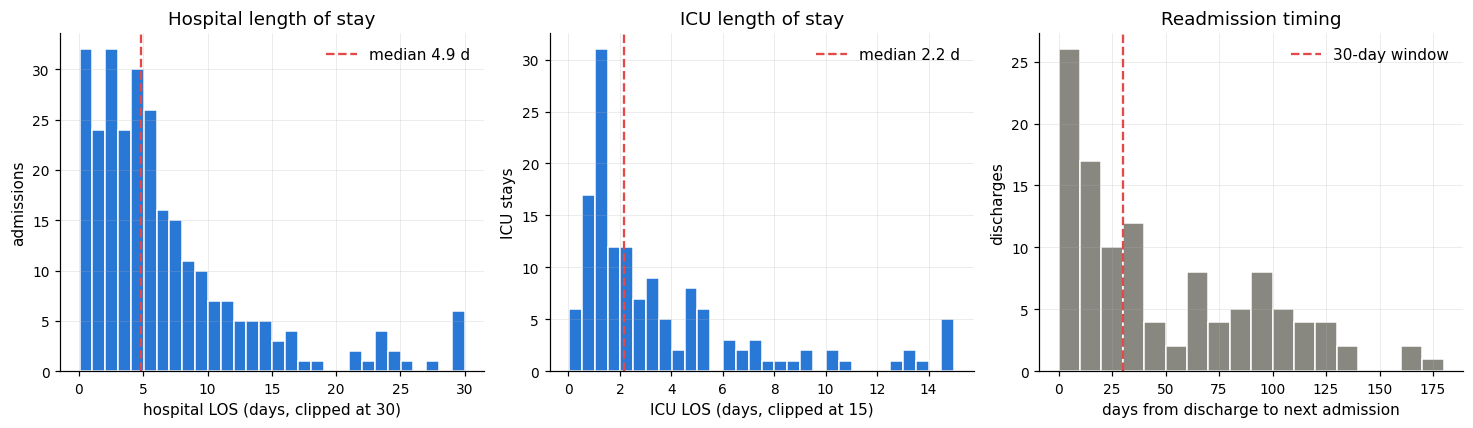

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

# Hospital LOS
ax = axes[0]
ax.hist(admissions.los_hosp_days.clip(0, 30), bins=30, color=ACCENT, edgecolor="white")
ax.axvline(admissions.los_hosp_days.median(), color=BAD, ls="--", lw=1.5,
           label=f"median {admissions.los_hosp_days.median():.1f} d")
ax.set_xlabel("hospital LOS (days, clipped at 30)"); ax.set_ylabel("admissions")
ax.set_title("Hospital length of stay"); ax.legend()

# ICU LOS
ax = axes[1]
ax.hist(icustays.los.clip(0, 15), bins=30, color=ACCENT, edgecolor="white")
ax.axvline(icustays.los.median(), color=BAD, ls="--", lw=1.5,
           label=f"median {icustays.los.median():.1f} d")
ax.set_xlabel("ICU LOS (days, clipped at 15)"); ax.set_ylabel("ICU stays")
ax.set_title("ICU length of stay"); ax.legend()

# Time to readmission
ax = axes[2]
d = alive.days_to_next.dropna()
d = d[d <= 180]
ax.hist(d, bins=np.arange(0, 185, 10), color=NEUTRAL, edgecolor="white")
ax.axvline(30, color=BAD, ls="--", lw=1.5, label="30-day window")
ax.set_xlabel("days from discharge to next admission"); ax.set_ylabel("discharges")
ax.set_title("Readmission timing"); ax.legend()

save(fig, "03_outcomes"); plt.show()

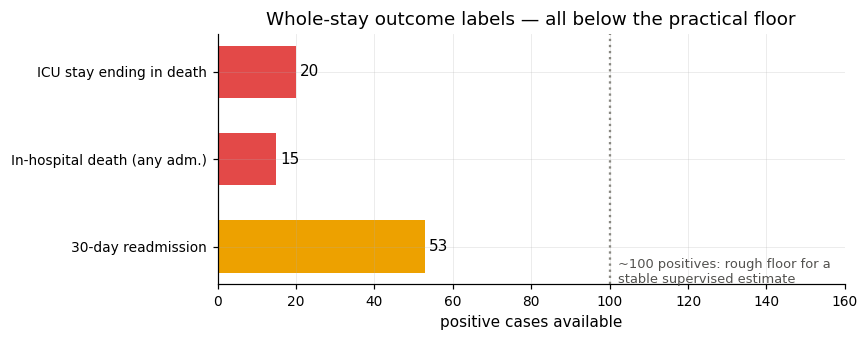

In [9]:
# The label-count picture that governs modelling ambition
label_counts = pd.Series({
    "30-day readmission":            readmit[30],
    "In-hospital death (any adm.)":  deaths,
    "ICU stay ending in death":      icu_deaths,
})
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(label_counts.index, label_counts.values,
               color=[WARN, BAD, BAD], height=0.6)
for y, v in enumerate(label_counts.values):
    ax.text(v + 1, y, str(v), va="center", fontsize=10)
ax.axvline(100, color=NEUTRAL, ls=":", lw=1.5)
ax.text(102, -0.45, "~100 positives: rough floor for a\nstable supervised estimate",
        fontsize=8.5, color="#52514e", va="bottom")
ax.set_xlabel("positive cases available"); ax.set_xlim(0, 160)
ax.set_title("Whole-stay outcome labels — all below the practical floor")
save(fig, "04_label_counts"); plt.show()

**Interpretation — this is the single most consequential finding for modelling.**

The whole-stay outcomes are severely underpowered. 20 ICU deaths and 53 readmissions cannot support a
defensible AUROC claim; a single fold's composition would swing the estimate wildly.

Two consequences follow, and both shape the build:

1. **The primary prediction task must be defined at the patient-hour level, not the stay level.** Predicting
   "deterioration within the next 6 hours" across ~12,000 patient-hours (constructed in section 5) has
   perhaps two orders of magnitude more learning signal than predicting mortality across 140 stays.
2. **Evaluation methodology carries the credibility, not the headline number.** Grouped splits by
   `subject_id`, repeated cross-validation, bootstrap confidence intervals, and comparison against a
   rule-based baseline. If the learned model does not beat NEWS2, that must be reported as the result.

The readmission timing histogram is more encouraging: readmissions cluster in the first 30 days, which is
the clinically actionable window and exactly what the post-discharge monitoring deliverable targets.

---
## 4. ICU monitoring — what "real-time" actually means here

The project specifies *continuous, real-time monitoring*. This section tests that assumption against the
data. It is the most important section in the notebook, because the answer determines the entire
streaming architecture.

In [10]:
chartevents = read_mimic("icu", "chartevents")
d_items     = read_mimic("icu", "d_items")
chartevents["charttime"] = pd.to_datetime(chartevents.charttime)

ce = chartevents.merge(d_items[["itemid", "label", "category", "param_type", "unitname"]],
                       on="itemid", how="left")

print(f"chartevents rows   : {len(chartevents):,}")
print(f"distinct item types: {chartevents.itemid.nunique():,}")
print(f"ICU stays covered  : {chartevents.stay_id.nunique()} / {len(icustays)}")
print(f"rows per stay      : median {chartevents.groupby('stay_id').size().median():,.0f}")

chartevents rows   : 668,862
distinct item types: 1,318
ICU stays covered  : 140 / 140
rows per stay      : median 2,520


In [11]:
cat = (ce.groupby("category")
         .agg(rows=("value", "size"), items=("itemid", "nunique"), stays=("stay_id", "nunique"))
         .sort_values("rows", ascending=False))
print("Charted categories (top 15):")
cat.head(15)

Charted categories (top 15):


,rows,items,stays
category,,,
Routine Vital Signs,90486,46,140
Restraint/Support Systems,81677,38,139
Respiratory,76851,99,140
Neurological,54137,65,140
Care Plans,50143,86,109
Treatments,49960,57,139
Pain/Sedation,38426,72,140
GI/GU,33435,43,139
Labs,25954,91,139


In [12]:
# Canonical vital-sign itemids (MIMIC-IV metavision)
VITALS = {
    "Heart rate":            220045,
    "Respiratory rate":      220210,
    "SpO2":                  220277,
    "NIBP systolic":         220179,
    "NIBP diastolic":        220180,
    "NIBP mean":             220181,
    "Arterial BP systolic":  220050,
    "Arterial BP mean":      220052,
    "Temperature (F)":       223761,
    "GCS - eye":             220739,
    "GCS - verbal":          223900,
    "GCS - motor":           223901,
    "FiO2":                  223835,
    "Glucose (fingerstick)": 225664,
}
N_STAYS = len(icustays)

rows = []
for name, iid in VITALS.items():
    s = chartevents[chartevents.itemid == iid]
    gaps = []
    for _, g in s.groupby("stay_id"):
        t = g.charttime.sort_values()
        if len(t) > 1:
            gaps.append(t.diff().dt.total_seconds().median() / 60)
    rows.append({
        "vital": name, "itemid": iid, "n_obs": len(s), "n_stays": s.stay_id.nunique(),
        "stay_coverage_pct": pct(s.stay_id.nunique(), N_STAYS),
        "median_gap_min": round(float(np.median(gaps)), 1) if gaps else np.nan,
        "median_value": s.valuenum.median(),
    })
vitals = pd.DataFrame(rows).sort_values("stay_coverage_pct", ascending=False).reset_index(drop=True)
vitals

,vital,itemid,n_obs,n_stays,stay_coverage_pct,median_gap_min,median_value
0,Heart rate,220045,13913,140,100.0,60.0,90.0
1,Respiratory rate,220210,13913,140,100.0,60.0,20.0
2,SpO2,220277,13540,140,100.0,60.0,97.0
3,GCS - eye,220739,3274,140,100.0,240.0,4.0
4,GCS - verbal,223900,3266,140,100.0,240.0,4.0
5,GCS - motor,223901,3251,140,100.0,240.0,6.0
6,NIBP systolic,220179,8347,139,99.3,60.0,113.0
7,NIBP diastolic,220180,8349,139,99.3,60.0,62.0
8,NIBP mean,220181,8342,138,98.6,60.0,74.0
9,Temperature (F),223761,3379,138,98.6,240.0,98.4


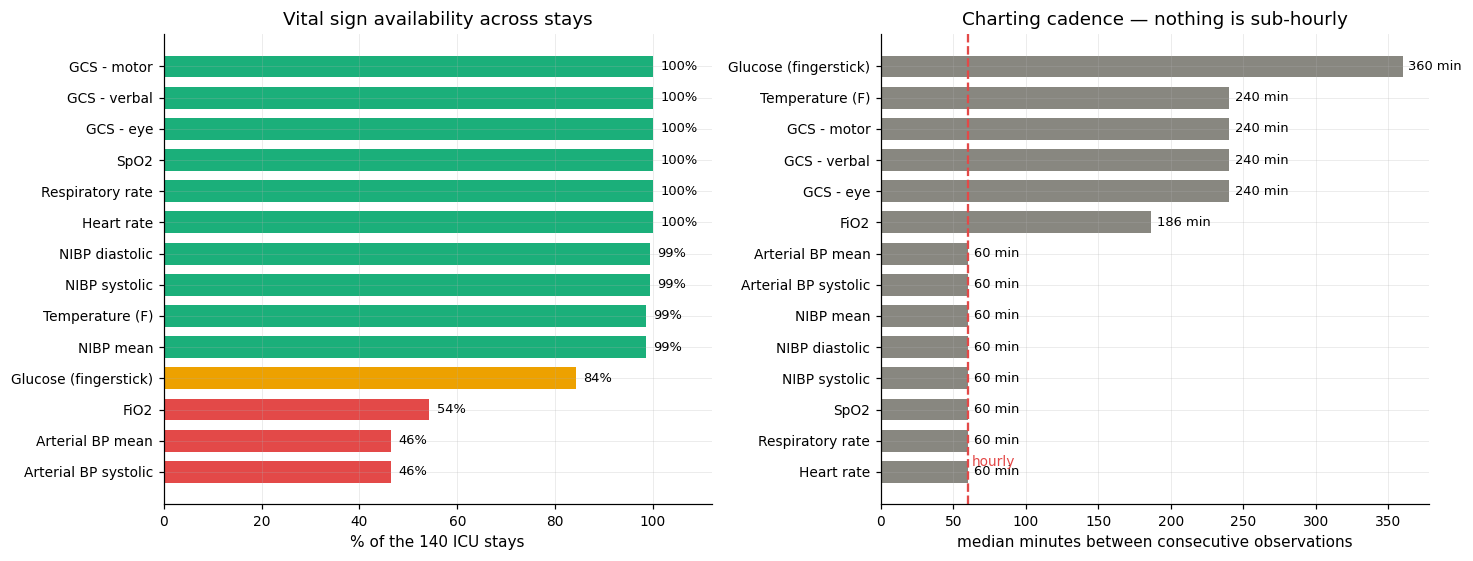

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

# Left: coverage across stays
ax = axes[0]
v = vitals.sort_values("stay_coverage_pct")
cols = [OK if c >= 95 else WARN if c >= 70 else BAD for c in v.stay_coverage_pct]
ax.barh(v.vital, v.stay_coverage_pct, color=cols, height=0.7)
for y, c in enumerate(v.stay_coverage_pct):
    ax.text(c + 1.5, y, f"{c:.0f}%", va="center", fontsize=8.5)
ax.set_xlim(0, 112); ax.set_xlabel(f"% of the {N_STAYS} ICU stays")
ax.set_title("Vital sign availability across stays")

# Right: median charting interval
ax = axes[1]
v2 = vitals.dropna(subset=["median_gap_min"]).sort_values("median_gap_min")
ax.barh(v2.vital, v2.median_gap_min, color=NEUTRAL, height=0.7)
for y, g in enumerate(v2.median_gap_min):
    ax.text(g + 4, y, f"{g:.0f} min", va="center", fontsize=8.5)
ax.axvline(60, color=BAD, ls="--", lw=1.5)
ax.text(63, 0.2, "hourly", color=BAD, fontsize=9)
ax.set_xlabel("median minutes between consecutive observations")
ax.set_title("Charting cadence — nothing is sub-hourly")

save(fig, "05_vitals_coverage"); plt.show()

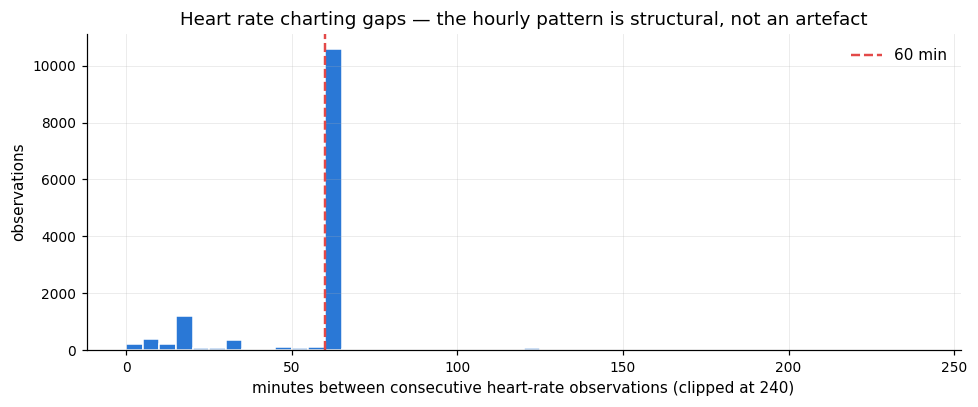

Share of HR gaps <= 5 min : 3.9%
Share of HR gaps 55-65 min: 77.7%
Median gap                : 60 min


In [14]:
# Distribution of inter-observation gaps for heart rate - is 60 min typical or an artefact of the median?
hr = chartevents[chartevents.itemid == 220045].sort_values(["stay_id", "charttime"])
hr_gaps = hr.groupby("stay_id").charttime.diff().dt.total_seconds() / 60
hr_gaps = hr_gaps.dropna()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(hr_gaps.clip(0, 240), bins=np.arange(0, 245, 5), color=ACCENT, edgecolor="white")
ax.axvline(60, color=BAD, ls="--", lw=1.6, label="60 min")
ax.set_xlabel("minutes between consecutive heart-rate observations (clipped at 240)")
ax.set_ylabel("observations")
ax.set_title("Heart rate charting gaps — the hourly pattern is structural, not an artefact")
ax.legend()
save(fig, "06_hr_gap_distribution"); plt.show()

print(f"Share of HR gaps <= 5 min : {pct((hr_gaps <= 5).sum(), len(hr_gaps))}%")
print(f"Share of HR gaps 55-65 min: {pct(((hr_gaps >= 55) & (hr_gaps <= 65)).sum(), len(hr_gaps))}%")
print(f"Median gap                : {hr_gaps.median():.0f} min")

**Interpretation — the defining constraint of this project.**

MIMIC-IV `chartevents` is a **nurse-validated charting record, not a bedside monitor stream.** Heart rate,
respiratory rate and SpO2 are present for 100% of stays, which is excellent coverage — but they arrive
once an hour. The gap histogram confirms this is structural: the mass sits at 60 minutes, not scattered
across short intervals.

This does not invalidate the project, but it forces three honest design decisions:

1. **The native analytic cadence is hourly.** Risk scores and early-warning logic are computed per
   patient-hour. This is defensible — NEWS2 in real hospitals is also scored intermittently, typically
   every 4–12 hours, so hourly is *better* than standard practice, not worse.
2. **"Real-time" must be produced, not assumed.** A replay simulator streams the hourly grid under time
   compression to exercise the streaming stack, and the live smartwatch supplies genuinely
   high-frequency data. Both are legitimate; presenting hourly charting as a live monitor feed would not be.
3. **Arterial BP (46%) and temperature cannot be treated as always-available.** Only the sickest patients
   get an arterial line, so its presence is itself informative — it is a *feature*, and the missingness
   indicator must be modelled explicitly rather than imputed away.

---
## 5. Building the hourly patient-state grid

This is the canonical modelling table the predictive deliverables will consume: one row per
`(stay_id, hour_since_ICU_admission)`. Constructing it here proves the pipeline works and quantifies
how much imputation the models will depend on.

In [15]:
GRID_ITEMS = {
    220045: "hr", 220210: "rr", 220277: "spo2",
    220179: "sbp_ni", 220181: "map_ni", 220050: "sbp_art", 220052: "map_art",
    223761: "temp_f", 223762: "temp_c",
    220739: "gcs_eye", 223900: "gcs_verbal", 223901: "gcs_motor",
    223835: "fio2", 225664: "glucose",
}

g = chartevents[chartevents.itemid.isin(GRID_ITEMS)].copy()
g["var"] = g.itemid.map(GRID_ITEMS)
g = g.merge(icustays[["stay_id", "intime", "los"]], on="stay_id", how="inner")
g["hour"] = ((g.charttime - g.intime).dt.total_seconds() // 3600).astype(int)
g = g[g.hour >= 0]

grid = (g.pivot_table(index=["stay_id", "hour"], columns="var", values="valuenum", aggfunc="mean")
          .reset_index())

# Unify the two temperature scales and the three GCS components
grid["temp_c"] = grid["temp_c"].fillna((grid["temp_f"] - 32) * 5 / 9)
grid["gcs_total"] = grid[["gcs_eye", "gcs_verbal", "gcs_motor"]].sum(axis=1, min_count=3)
# Prefer arterial pressure where a line exists, else non-invasive
grid["sbp"] = grid["sbp_art"].fillna(grid["sbp_ni"])
grid["map"] = grid["map_art"].fillna(grid["map_ni"])

print(f"Hourly grid: {len(grid):,} patient-hours across {grid.stay_id.nunique()} ICU stays")
print(f"Mean hours per stay: {len(grid) / grid.stay_id.nunique():.1f}")
grid.head()

Hourly grid: 12,004 patient-hours across 140 ICU stays
Mean hours per stay: 85.7


var,stay_id,hour,fio2,gcs_eye,gcs_motor,gcs_verbal,glucose,hr,map_art,map_ni,rr,sbp_art,sbp_ni,spo2,temp_c,temp_f,gcs_total,sbp,map
0,30057454,0,NaN,NaN,NaN,NaN,NaN,107.2,75.0,NaN,17.800000,96.800000,NaN,93.000000,36.805556,98.25,NaN,96.800000,75.0
1,30057454,1,NaN,4.0,6.0,5.0,NaN,103.0,72.0,NaN,21.333333,93.333333,NaN,94.333333,NaN,NaN,15.0,93.333333,72.0
2,30057454,2,NaN,NaN,NaN,NaN,NaN,108.0,76.0,NaN,23.000000,99.000000,NaN,95.000000,NaN,NaN,NaN,99.000000,76.0
3,30057454,3,NaN,NaN,NaN,NaN,NaN,105.0,78.0,NaN,18.000000,102.000000,NaN,94.000000,NaN,NaN,NaN,102.000000,78.0
4,30057454,4,NaN,NaN,NaN,NaN,NaN,106.0,79.0,NaN,21.000000,105.000000,NaN,92.000000,37.055556,98.70,NaN,105.000000,79.0


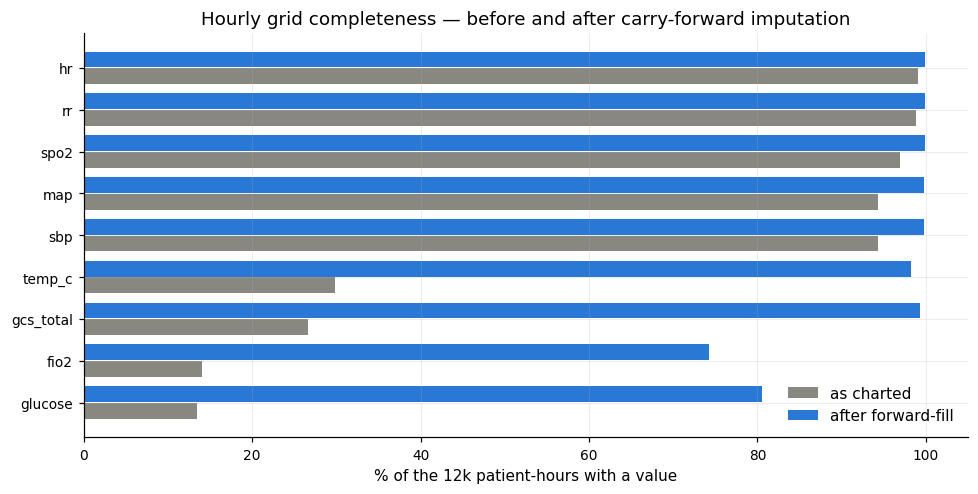

,raw,after_ffill
glucose,13.4,80.5
fio2,14.0,74.2
gcs_total,26.7,99.3
temp_c,29.8,98.3
sbp,94.3,99.7
map,94.3,99.7
spo2,96.9,99.9
rr,98.9,99.9
hr,99.0,99.9


In [16]:
CORE = ["hr", "rr", "spo2", "sbp", "map", "temp_c", "gcs_total", "fio2", "glucose"]
raw_completeness = (grid[CORE].notna().mean() * 100).sort_values(ascending=False)

# Forward-fill within stay, as any production feature store would, and re-measure
filled = grid.sort_values(["stay_id", "hour"]).copy()
for c in CORE:
    filled[c + "_ffill"] = filled.groupby("stay_id")[c].ffill()
ffill_completeness = (filled[[c + "_ffill" for c in CORE]].notna().mean() * 100)
ffill_completeness.index = CORE

comp = pd.DataFrame({"raw": raw_completeness, "after_ffill": ffill_completeness}).sort_values("raw")

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(comp))
ax.barh(y - 0.2, comp.raw, height=0.38, color=NEUTRAL, label="as charted")
ax.barh(y + 0.2, comp.after_ffill, height=0.38, color=ACCENT, label="after forward-fill")
ax.set_yticks(y); ax.set_yticklabels(comp.index)
ax.set_xlabel("% of the 12k patient-hours with a value"); ax.set_xlim(0, 105)
ax.set_title("Hourly grid completeness — before and after carry-forward imputation")
ax.legend(loc="lower right")
save(fig, "07_grid_completeness"); plt.show()

comp.round(1)

**Interpretation.** Roughly 12,000 patient-hours — about 85× more training rows than the 140 whole-stay
labels, which is precisely why the primary task must live at this granularity.

Heart rate, respiratory rate and SpO2 are near-complete as charted. Blood pressure sits around 60% and
temperature around 27%, because they are charted on a slower schedule than the continuously displayed
monitor values. Forward-filling within a stay lifts everything above 90%.

The design rule this establishes: **carry-forward is mandatory, and every imputed cell must be flagged.**
A model that cannot distinguish "SBP is 110 because it was just measured" from "SBP is 110 because it was
measured four hours ago" will be dangerously overconfident in exactly the situations that matter. The
feature set therefore needs `*_was_imputed` and `hours_since_last_observation` columns alongside each value.

---
## 6. Event density across the whole hospital stay

Sections 4 and 5 characterised ICU vitals specifically. This section zooms out to *every* timestamped
event in the record — labs, provider orders, medication administrations, ICU charting, interventions,
cultures and transfers — and asks how they are distributed across the hospital stay.

This is an **arrival-process** question rather than a coverage question, and three deliverables depend
on the answer: the replay simulator needs a realistic event-timing distribution, the feature store needs
to know whether measurement frequency is itself a signal, and the alerting engine needs to know when the
record goes quiet.

One methodological point governs the whole section. Naively counting events per hour since admission
produces a curve that decays to zero — but that mostly reflects *patients being discharged*, not the
record going quiet. Every rate below is therefore divided by the **at-risk denominator**: the number of
admissions still in hospital at that hour.

In [17]:
# Every table in the demo that carries a timestamp and an hadm_id, grouped into clinical event families
EVENT_SOURCES = [
    ("ICU monitoring",    "icu",  "chartevents",        "charttime"),
    ("ICU monitoring",    "icu",  "datetimeevents",     "charttime"),
    ("Labs",              "hosp", "labevents",          "charttime"),
    ("Medications",       "hosp", "emar",               "charttime"),
    ("Medications",       "hosp", "prescriptions",      "starttime"),
    ("Provider orders",   "hosp", "poe",                "ordertime"),
    ("ICU interventions", "icu",  "inputevents",        "starttime"),
    ("ICU interventions", "icu",  "outputevents",       "charttime"),
    ("ICU interventions", "icu",  "procedureevents",    "starttime"),
    ("Microbiology",      "hosp", "microbiologyevents", "charttime"),
    ("Transfers",         "hosp", "transfers",          "intime"),
]

frames = []
for group, module, table, tcol in EVENT_SOURCES:
    df = read_mimic(module, table)
    if tcol not in df.columns or "hadm_id" not in df.columns:
        print(f"  skipped {module}/{table} (no {tcol}/hadm_id)")
        continue
    sub = df[["hadm_id", tcol]].copy()
    sub.columns = ["hadm_id", "event_time"]
    sub["event_time"]   = pd.to_datetime(sub.event_time, errors="coerce")
    sub["group"]        = group
    sub["source_table"] = f"{module}/{table}"
    frames.append(sub)

events = pd.concat(frames, ignore_index=True)
print(f"Timestamped events pooled : {len(events):,}")
events = events.dropna(subset=["hadm_id", "event_time"])
events["hadm_id"] = events.hadm_id.astype(int)
print(f"With a valid hadm_id+time : {len(events):,}")

events.groupby(["group", "source_table"]).size().rename("events").reset_index().sort_values("events", ascending=False)

Timestamped events pooled : 926,268
With a valid hadm_id+time : 895,817


,group,source_table,events
3,ICU monitoring,icu/chartevents,668862
5,Labs,hosp/labevents,79307
9,Provider orders,hosp/poe,45154
6,Medications,hosp/emar,34829
0,ICU interventions,icu/inputevents,20404
7,Medications,hosp/prescriptions,18087
4,ICU monitoring,icu/datetimeevents,15280
1,ICU interventions,icu/outputevents,9362
8,Microbiology,hosp/microbiologyevents,1928
2,ICU interventions,icu/procedureevents,1468


In [18]:
adm_win = admissions[["hadm_id", "subject_id", "admittime", "dischtime",
                      "hospital_expire_flag", "los_hosp_days"]]
ev = events.merge(adm_win, on="hadm_id", how="inner")
ev["hours_since_admit"] = (ev.event_time - ev.admittime).dt.total_seconds() / 3600
ev["stay_hours"]        = ev.los_hosp_days * 24
ev["pct_of_stay"]       = ev.hours_since_admit / ev.stay_hours * 100

before = int((ev.hours_since_admit < 0).sum())
after   = int((ev.pct_of_stay > 100).sum())
iw = ev[(ev.hours_since_admit >= 0) & (ev.pct_of_stay <= 100)].copy()

print(f"Events inside the admission window : {len(iw):,}")
print(f"  before admittime (pre-admission / ED work-up): {before:,} ({pct(before, len(ev))}%)")
print(f"  after dischtime  (outpatient follow-up)      : {after:,} ({pct(after, len(ev))}%)")
print(f"\nEvents per admission: median {iw.groupby('hadm_id').size().median():,.0f}, "
      f"max {iw.groupby('hadm_id').size().max():,}")
print(f"Events per patient-day: median "
      f"{(iw.groupby('hadm_id').size() / adm_win.set_index('hadm_id').los_hosp_days).median():.0f}")

Events inside the admission window : 884,775
  before admittime (pre-admission / ED work-up): 5,341 (0.6%)
  after dischtime  (outpatient follow-up)      : 5,701 (0.6%)

Events per admission: median 942, max 42,448
Events per patient-day: median 128


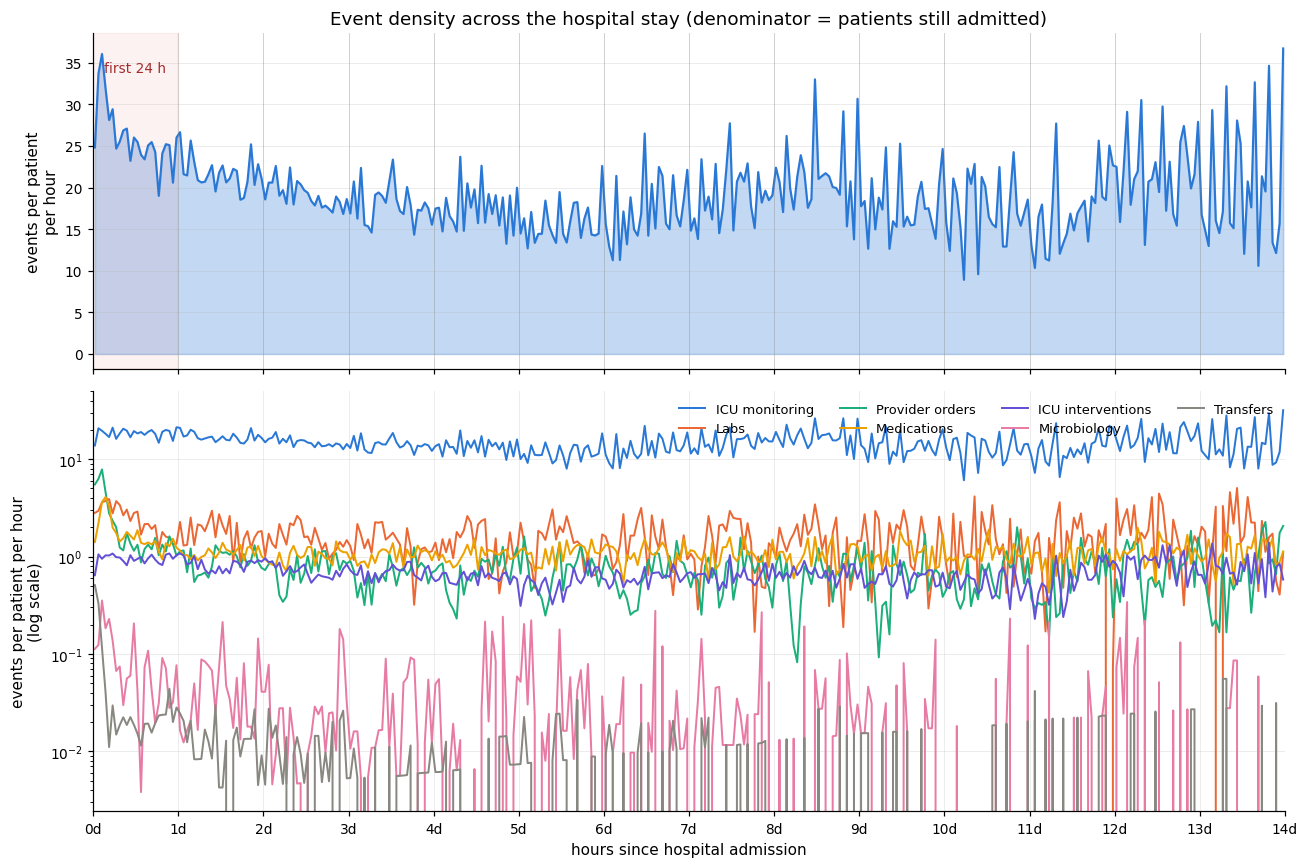

Peak hour rate (hour 0-1)        : 33.7 events/patient/hour
Mean rate, first 24 h            : 26.04
Mean rate, day 2-7               : 18.22
Admission burst, 24 h mean       : 1.43x
Admission burst, peak hour       : 1.85x

Admissions still in hospital:  0d=275   1d=245   2d=220   3d=188   5d=135   7d=91   10d=57   13d=37

Per-family burst ratio (first 24 h mean / day 2-7 mean):
  ICU monitoring      1.31x
  Labs                1.61x
  Provider orders     2.89x
  Medications         1.66x
  ICU interventions   1.42x
  Microbiology        2.45x
  Transfers           7.54x


In [19]:
MAXH  = 336                                    # 14 days
bins  = np.arange(0, MAXH + 1, 1)
centres = bins[:-1] + 0.5

# At-risk denominator: admissions still in hospital at each hour
at_risk = np.array([int((adm_win.los_hosp_days * 24 > h).sum()) for h in bins[:-1]])
at_risk = np.maximum(at_risk, 1)

GROUPS = ["ICU monitoring", "Labs", "Provider orders", "Medications",
          "ICU interventions", "Microbiology", "Transfers"]
GCOL = dict(zip(GROUPS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                         "#6250d6", "#e87ba4", "#888780"], strict=False))

sub = iw[iw.hours_since_admit < MAXH]
rates = {}
for g in GROUPS:
    cnt, _ = np.histogram(sub[sub.group == g].hours_since_admit, bins=bins)
    rates[g] = cnt / at_risk

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1.25]})

# Total event rate per patient still in hospital
ax = axes[0]
total = np.sum([rates[g] for g in GROUPS], axis=0)
ax.fill_between(centres, total, color=ACCENT, alpha=0.28)
ax.plot(centres, total, color=ACCENT, lw=1.4)
for d in range(1, 15):
    ax.axvline(d * 24, color=NEUTRAL, lw=0.5, alpha=0.35)
ax.set_ylabel("events per patient\nper hour")
ax.set_title("Event density across the hospital stay (denominator = patients still admitted)")
ax.axvspan(0, 24, color=BAD, alpha=0.07)
ax.text(3, ax.get_ylim()[1] * 0.88, "first 24 h", color="#a32d2d", fontsize=9)

# Where the at-risk denominator thins out the rate becomes unstable - mark it rather than read into it
thin = np.where(at_risk < 30)[0]
if len(thin):
    ax.axvspan(centres[thin[0]], MAXH, color=NEUTRAL, alpha=0.18)
    ax.text(centres[thin[0]] + 5, ax.get_ylim()[1] * 0.88,
            "<30 admissions still in hospital — rate unstable beyond here",
            fontsize=8.5, color="#444441")

# Broken out by event family
ax = axes[1]
for g in GROUPS:
    ax.plot(centres, rates[g], lw=1.3, color=GCOL[g], label=g)
if len(thin):
    ax.axvspan(centres[thin[0]], MAXH, color=NEUTRAL, alpha=0.18)
ax.set_yscale("log")
ax.set_xlabel("hours since hospital admission")
ax.set_ylabel("events per patient per hour\n(log scale)")
ax.set_xlim(0, MAXH); ax.set_xticks(np.arange(0, MAXH + 1, 24))
ax.set_xticklabels([f"{d}d" for d in range(0, 15)])
ax.legend(ncol=4, fontsize=8.5, loc="upper right")
save(fig, "18_event_density_absolute"); plt.show()

first24 = total[:24].mean()
stable  = total[24:168].mean()                 # day 2-7, where the denominator is still healthy
print(f"Peak hour rate (hour 0-1)        : {total[:2].max():.1f} events/patient/hour")
print(f"Mean rate, first 24 h            : {first24:.2f}")
print(f"Mean rate, day 2-7               : {stable:.2f}")
print(f"Admission burst, 24 h mean       : {first24/stable:.2f}x")
print(f"Admission burst, peak hour       : {total[:2].max()/stable:.2f}x")
print("\nAdmissions still in hospital:  " +
      "   ".join(f"{d}d={at_risk[d*24]}" for d in [0, 1, 2, 3, 5, 7, 10, 13]))

# Which families actually drive the burst?
print("\nPer-family burst ratio (first 24 h mean / day 2-7 mean):")
for g in GROUPS:
    r = rates[g]
    if r[24:168].mean() > 0:
        print(f"  {g:<18} {r[:24].mean()/r[24:168].mean():>5.2f}x")

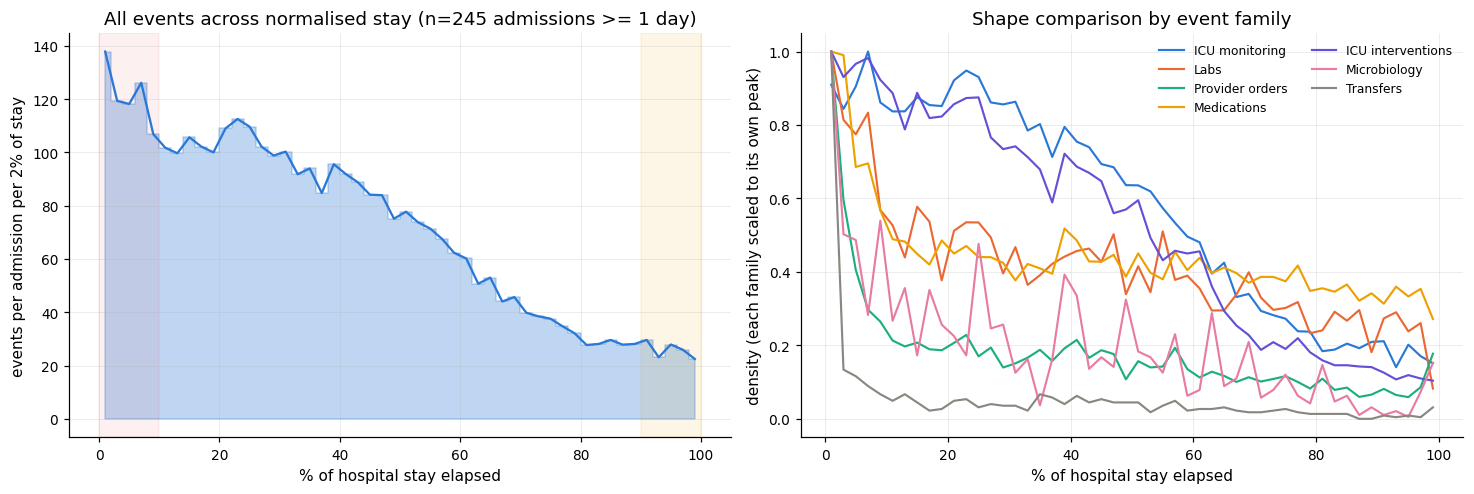

Share of all events in the first 10% of the stay: 16.9%
Share of all events in the last  10% of the stay: 3.6%


In [20]:
# Normalised stay progress - puts short and long admissions on one axis, exposing the discharge taper
NB = 50
long_stays = iw[iw.los_hosp_days >= 1]
edges = np.linspace(0, 100, NB + 1)
mid   = (edges[:-1] + edges[1:]) / 2
n_adm = long_stays.hadm_id.nunique()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

ax = axes[0]
cnt, _ = np.histogram(long_stays.pct_of_stay, bins=edges)
ax.fill_between(mid, cnt / n_adm, color=ACCENT, alpha=0.3, step="mid")
ax.plot(mid, cnt / n_adm, color=ACCENT, lw=1.5)
ax.set_xlabel("% of hospital stay elapsed"); ax.set_ylabel("events per admission per 2% of stay")
ax.set_title(f"All events across normalised stay (n={n_adm} admissions >= 1 day)")
ax.axvspan(0, 10, color=BAD, alpha=0.08); ax.axvspan(90, 100, color=WARN, alpha=0.10)

ax = axes[1]
for g in GROUPS:
    c, _ = np.histogram(long_stays[long_stays.group == g].pct_of_stay, bins=edges)
    if c.sum() == 0:
        continue
    ax.plot(mid, c / c.max(), lw=1.4, color=GCOL[g], label=g)
ax.set_xlabel("% of hospital stay elapsed"); ax.set_ylabel("density (each family scaled to its own peak)")
ax.set_title("Shape comparison by event family")
ax.legend(ncol=2, fontsize=8)
save(fig, "19_event_density_normalised"); plt.show()

head = cnt[:5].sum() / cnt.sum() * 100
tail = cnt[-5:].sum() / cnt.sum() * 100
print(f"Share of all events in the first 10% of the stay: {head:.1f}%")
print(f"Share of all events in the last  10% of the stay: {tail:.1f}%")

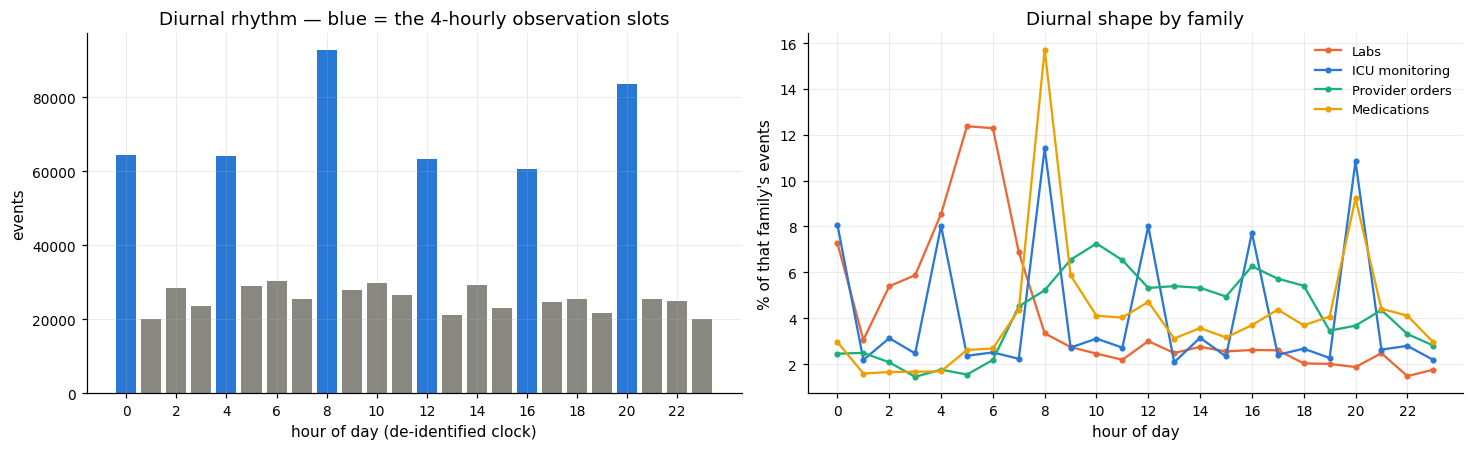

Share of all events landing on a 4-hourly slot (00/04/08/12/16/20): 48.4%   (uniform would be 25%)

Per-family peak hour:
  Labs             05:00   (12.4% of that family's events)
  Medications      08:00   (15.7% of that family's events)
  ICU monitoring   08:00   (11.4% of that family's events)
  Provider orders  10:00   (7.3% of that family's events)


In [21]:
# Diurnal structure - drives alert-fatigue modelling and on-call notification policy
iw["hour_of_day"] = iw.event_time.dt.hour
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))

Q4 = [0, 4, 8, 12, 16, 20]
ax = axes[0]
hod = iw.groupby("hour_of_day").size()
ax.bar(hod.index, hod.values, color=[ACCENT if h in Q4 else NEUTRAL for h in hod.index], width=0.8)
ax.set_xlabel("hour of day (de-identified clock)"); ax.set_ylabel("events")
ax.set_title("Diurnal rhythm — blue = the 4-hourly observation slots")
ax.set_xticks(range(0, 24, 2))

ax = axes[1]
for g in ["Labs", "ICU monitoring", "Provider orders", "Medications"]:
    h = iw[iw.group == g].groupby("hour_of_day").size()
    ax.plot(h.index, h.values / h.sum() * 100, lw=1.5, color=GCOL[g], marker="o", ms=3, label=g)
ax.set_xlabel("hour of day"); ax.set_ylabel("% of that family's events")
ax.set_title("Diurnal shape by family"); ax.legend(fontsize=8.5); ax.set_xticks(range(0, 24, 2))
save(fig, "20_event_diurnal"); plt.show()

print(f"Share of all events landing on a 4-hourly slot (00/04/08/12/16/20): "
      f"{pct(hod[Q4].sum(), hod.sum())}%   (uniform would be 25%)")
print("\nPer-family peak hour:")
for g in ["Labs", "Medications", "ICU monitoring", "Provider orders"]:
    h = iw[iw.group == g].groupby("hour_of_day").size()
    print(f"  {g:<16} {h.idxmax():02d}:00   ({pct(h.max(), h.sum())}% of that family's events)")

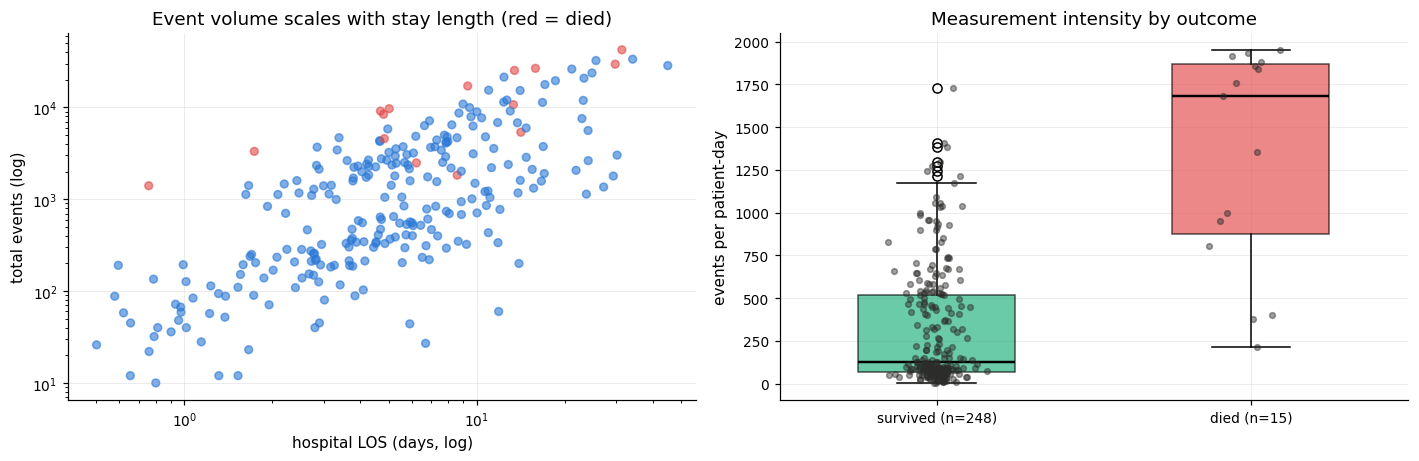

Median events/patient-day  survived 125   died 1683   ratio 13.5x
Mann-Whitney (died > survived): p = 5e-08   [n_died = 15]

Stratified by ICU exposure:
                                n  median_events_per_day
had_icu hospital_expire_flag                            
False   0                     135                   73.0
True    0                     113                  533.0
        1                      15                 1683.0


In [22]:
# Is event rate itself predictive? (informative-measurement hypothesis)
per_adm = (iw.groupby("hadm_id").size().rename("events").to_frame()
             .join(adm_win.set_index("hadm_id")[["los_hosp_days", "hospital_expire_flag"]]))
per_adm["events_per_day"] = per_adm.events / per_adm.los_hosp_days.clip(lower=0.5)
per_adm = per_adm[per_adm.los_hosp_days > 0.5]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
ax.scatter(per_adm.los_hosp_days, per_adm.events, s=26, alpha=0.6,
           c=[BAD if f == 1 else ACCENT for f in per_adm.hospital_expire_flag])
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("hospital LOS (days, log)"); ax.set_ylabel("total events (log)")
ax.set_title("Event volume scales with stay length (red = died)")

ax = axes[1]
d = [per_adm[per_adm.hospital_expire_flag == 0].events_per_day,
     per_adm[per_adm.hospital_expire_flag == 1].events_per_day]
bp = ax.boxplot(d, labels=[f"survived (n={len(d[0])})", f"died (n={len(d[1])})"],
                patch_artist=True, widths=0.5, medianprops=dict(color="black", lw=1.6))
for patch, c in zip(bp["boxes"], [OK, BAD], strict=False):
    patch.set_facecolor(c); patch.set_alpha(0.65)
for i, x in enumerate(d, start=1):
    ax.scatter(np.random.normal(i, 0.045, len(x)), x, s=14, color="#2c2c2a", alpha=0.45, zorder=3)
ax.set_ylabel("events per patient-day")
ax.set_title("Measurement intensity by outcome")
save(fig, "21_event_rate_vs_outcome"); plt.show()

from scipy.stats import mannwhitneyu

surv = per_adm[per_adm.hospital_expire_flag == 0].events_per_day
died = per_adm[per_adm.hospital_expire_flag == 1].events_per_day
_, pval = mannwhitneyu(died, surv, alternative="greater")
print(f"Median events/patient-day  survived {surv.median():.0f}   died {died.median():.0f}   "
      f"ratio {died.median()/surv.median():.1f}x")
print(f"Mann-Whitney (died > survived): p = {pval:.2g}   [n_died = {len(died)}]")

# Confound check: is this just ICU exposure? Split by whether the admission included an ICU stay.
per_adm["had_icu"] = per_adm.index.isin(set(icustays.hadm_id))
tbl = (per_adm.groupby(["had_icu", "hospital_expire_flag"])
              .agg(n=("events_per_day", "size"), median_events_per_day=("events_per_day", "median"))
              .round(0))
print("\nStratified by ICU exposure:")
print(tbl.to_string())

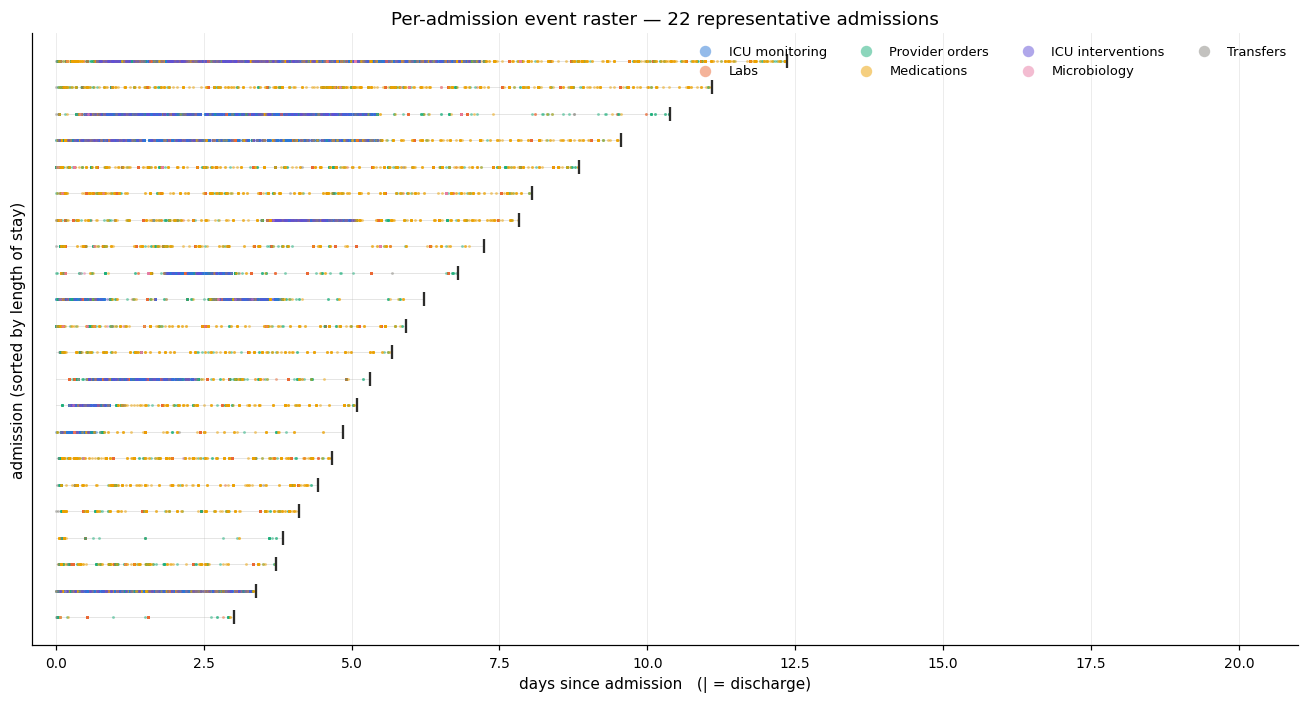

In [23]:
# Per-admission raster - what an individual record actually looks like to a streaming consumer
pick = (adm_win[(adm_win.los_hosp_days >= 3) & (adm_win.los_hosp_days <= 20)]
        .sort_values("los_hosp_days").hadm_id.tolist())
pick = pick[:: max(1, len(pick) // 22)][:22]

r = iw[iw.hadm_id.isin(pick)]
order = {h: i for i, h in enumerate(pick)}

fig, ax = plt.subplots(figsize=(12, 6.5))
for g in GROUPS:
    s = r[r.group == g]
    ax.scatter(s.hours_since_admit / 24, s.hadm_id.map(order),
               s=3.5, alpha=0.5, color=GCOL[g], label=g, linewidths=0)
for h, i in order.items():
    los = float(adm_win.loc[adm_win.hadm_id == h, "los_hosp_days"].iloc[0])
    ax.plot([0, los], [i, i], color=NEUTRAL, lw=0.4, alpha=0.35, zorder=0)
    ax.scatter([los], [i], marker="|", s=90, color="#2c2c2a", zorder=4)
ax.set_xlabel("days since admission   (| = discharge)")
ax.set_ylabel("admission (sorted by length of stay)")
ax.set_yticks([]); ax.set_xlim(-0.4, 21)
ax.set_title("Per-admission event raster — 22 representative admissions")
leg = ax.legend(ncol=4, fontsize=8.5, loc="upper right", markerscale=4)
save(fig, "22_event_raster"); plt.show()

**Interpretation.** Four findings, and each one changes an implementation decision. Note that several
cut against the intuition one would bring to this plot.

**1. The admission burst is real but modest — and it is an *ordering* burst, not a monitoring burst.**
Peak rate is 33.7 events/patient/hour in the first hour against an 18.2 day-2-to-7 baseline: 1.85× at the
peak, and only 1.43× averaged over the whole first 24 hours. That is far smaller than the classic MIMIC
front-loading story suggests.

The per-family breakdown explains why, and is the more useful result. Transfers burst 7.5×, provider
orders 2.9×, microbiology 2.5× — but **ICU monitoring barely moves at 1.31×**. The admission spike is
registration, order sets and baseline cultures. The physiological monitoring stream is close to
stationary from the moment it starts.

*Consequence for the replay simulator:* one global arrival rate would be wrong in both directions. Model
each family separately — bursty Poisson for orders and transfers, near-stationary with a 4-hourly comb
for monitoring. Size load tests against 33.7 events/patient/hour, not the ~20 mean.

**2. The discharge taper is a much stronger effect than the admission burst, and it is the real leakage
trap.** 16.9% of all events fall in the first 10% of the stay against 3.6% in the last 10% — a 4.7×
gradient, versus the burst's 1.4×. On the normalised axis, density falls roughly six-fold from admission
to discharge.

*Consequence for modelling:* any model given a stay-relative window can learn "the record has gone quiet"
as a proxy for "about to be discharged alive." Prediction windows must be anchored to hours since ICU
admission — a fixed origin — never to position within the stay, and labels must be evaluated only on
windows ending strictly before the outcome.

**3. Monitoring density collapses at the ICU-to-ward step-down, and that is precisely this project's
thesis.** In the per-family normalised panel, ICU monitoring and ICU interventions hold near their peak
until roughly 55–60% of the stay, then fall off a cliff, while labs and medications decline gently.
That cliff is the transition out of the ICU.

This is the strongest data-driven argument for the platform: **the patient does not stop being at risk at
that point, but the observation stream largely stops.** The post-discharge wearable arm is aimed exactly
at the gap this figure makes visible. Worth putting in the report as a motivating chart rather than only
as an EDA artefact.

**4. Measurement intensity does track outcome — but far less than it first appears.** The naive comparison
is dramatic: 125 events/patient-day for survivors against 1,683 for decedents, a 13.5× gap at p ≈ 5e-08.

That number is badly confounded, and the stratification shows why: **all 15 deaths occurred in
ICU-exposed admissions**, and ICU exposure alone moves the rate from 73 to 533 events/patient-day, a 7.3×
effect. Comparing like with like — within ICU-exposed admissions only — decedents sit at 1,683 against
533, roughly **3.2×**. Real, but a quarter of the headline figure.

*Consequence for the feature store:* rolling event counts and time-since-last-event per channel are
legitimate features, but they must be normalised by care setting. An un-normalised version would mostly
learn "this patient is in the ICU," which the model already knows.

**5. Care is delivered on a 4-hourly clock, with four distinct family rhythms.** 48.4% of all events land
on the 00/04/08/12/16/20 slots against 25% under uniformity. The families separate cleanly: labs peak at
05:00 (the pre-dawn phlebotomy round, 12.4% of lab events), medications at 08:00 (15.7% — the morning drug
round), ICU monitoring at 08:00 with a visible 4-hourly comb, and provider orders at 10:00 following the
working day.

*Consequence for the alerting engine:* alerts will naturally cluster into six synchronised bursts per day.
Deduplication and suppression windows must align to that rhythm or the clinician sees a wall of
simultaneous alerts six times daily. The 05:00 lab round is the worst case — it triggers when staffing is
thinnest, so escalation policy needs an explicit overnight path. False-alarm evaluation in the validation
framework must be stratified by hour of day.

**Two caveats on reading these curves.**

- **Late-stay instability.** The at-risk denominator falls from 275 admissions at day 0 to 91 by day 7 and
  37 by day 13. The rising, spiky behaviour past roughly day 7 in the first figure is small-sample noise,
  not a genuine late-stay escalation — hence the shaded region. Do not read structure there.
- **De-identified clocks.** MIMIC timestamps are date-shifted, but the shift preserves time-of-day and all
  intervals, so the diurnal and inter-arrival structure above is genuine. The absolute wall-clock is not,
  so "05:00" should be read as a consistent pre-dawn slot rather than a literal local time.

A small bonus finding: 0.6% of events fall after `dischtime`. Tiny, but these are genuine post-discharge
outpatient results — the only real post-discharge signal anywhere in the dataset.

---
## 7. NEWS2 — is a working early-warning signal already present?

Before training anything, test whether the standard clinical deterioration score can be computed from
this data. NEWS2 (National Early Warning Score 2) is the NHS standard and will serve as both a
deliverable in its own right and the baseline every learned model must beat.

In [24]:
def news2_row(r):
    '''NEWS2 (RCP 2017), Scale 1. Returns (score, n_components_available).'''
    s, n = 0, 0
    if pd.notna(r.rr):
        n += 1
        s += 3 if r.rr <= 8 else 1 if r.rr <= 11 else 0 if r.rr <= 20 else 2 if r.rr <= 24 else 3
    if pd.notna(r.spo2):
        n += 1
        s += 3 if r.spo2 <= 91 else 2 if r.spo2 <= 93 else 1 if r.spo2 <= 95 else 0
    if pd.notna(r.sbp):
        n += 1
        s += 3 if r.sbp <= 90 else 2 if r.sbp <= 100 else 1 if r.sbp <= 110 else 0 if r.sbp <= 219 else 3
    if pd.notna(r.hr):
        n += 1
        s += 3 if r.hr <= 40 else 1 if r.hr <= 50 else 0 if r.hr <= 90 else 1 if r.hr <= 110 else 2 if r.hr <= 130 else 3
    if pd.notna(r.temp_c):
        n += 1
        s += 3 if r.temp_c <= 35 else 1 if r.temp_c <= 36 else 0 if r.temp_c <= 38 else 1 if r.temp_c <= 39 else 2
    if pd.notna(r.gcs_total):
        n += 1
        s += 0 if r.gcs_total >= 15 else 3          # NEWS2 scores any non-alert state as 3
    if pd.notna(r.fio2):
        n += 1
        s += 2 if r.fio2 > 21 else 0                # supplemental oxygen
    return pd.Series({"news2": s, "components": n})

ff = filled.copy()
for c in CORE:
    ff[c] = ff[c + "_ffill"]
ff[["news2", "components"]] = ff.apply(news2_row, axis=1)

print(f"NEWS2 computed for {len(ff):,} patient-hours")
print(f"Median components available per hour: {ff.components.median():.0f} / 7")
print(ff.news2.describe().round(2).to_string())

NEWS2 computed for 12,004 patient-hours
Median components available per hour: 7 / 7
count    12004.00
mean         6.26
std          2.93
min          0.00
25%          4.00
50%          6.00
75%          8.00
max         18.00


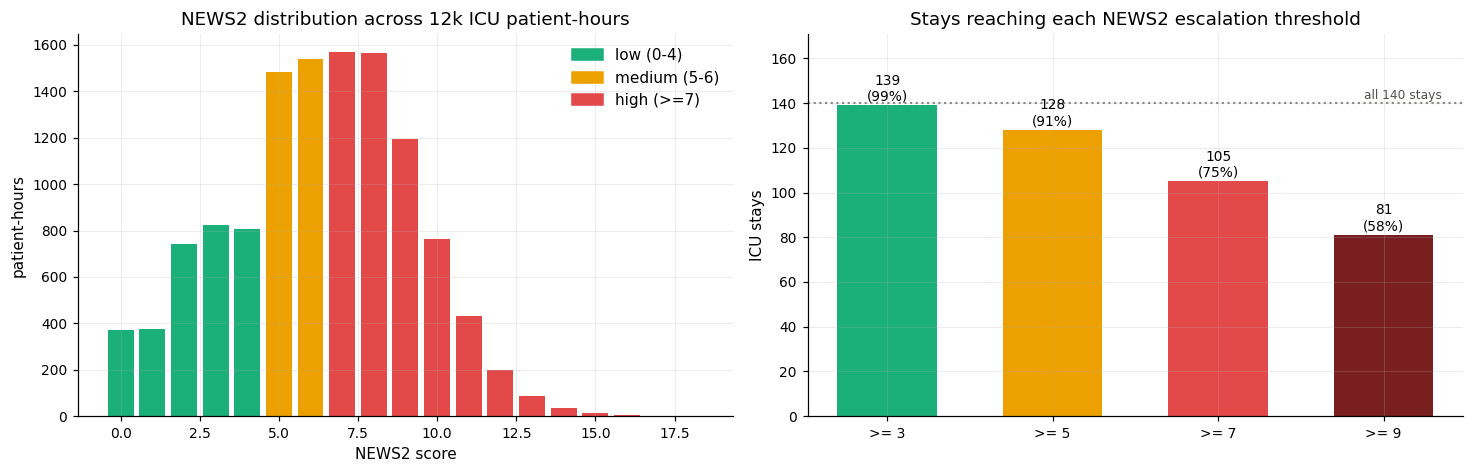

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

# Distribution with clinical escalation bands
ax = axes[0]
counts = ff.news2.value_counts().sort_index()
band = [OK if k <= 4 else WARN if k <= 6 else BAD for k in counts.index]
ax.bar(counts.index, counts.values, color=band, width=0.82)
ax.set_xlabel("NEWS2 score"); ax.set_ylabel("patient-hours")
ax.set_title("NEWS2 distribution across 12k ICU patient-hours")
handles = [plt.Rectangle((0,0),1,1, color=c) for c in (OK, WARN, BAD)]
ax.legend(handles, ["low (0-4)", "medium (5-6)", "high (>=7)"])

# How many stays ever cross each threshold
ax = axes[1]
th = [3, 5, 7, 9]
reached = [ff[ff.news2 >= t].stay_id.nunique() for t in th]
ax.bar([f">= {t}" for t in th], reached, color=[OK, WARN, BAD, "#791f1f"], width=0.6)
for i, v in enumerate(reached):
    ax.text(i, v + 2, f"{v}\n({pct(v, N_STAYS):.0f}%)", ha="center", fontsize=9)
ax.axhline(N_STAYS, color=NEUTRAL, ls=":", lw=1.4)
ax.text(3.35, N_STAYS + 2, "all 140 stays", fontsize=8, color="#52514e", ha="right")
ax.set_ylabel("ICU stays"); ax.set_ylim(0, N_STAYS * 1.22)
ax.set_title("Stays reaching each NEWS2 escalation threshold")

save(fig, "08_news2"); plt.show()

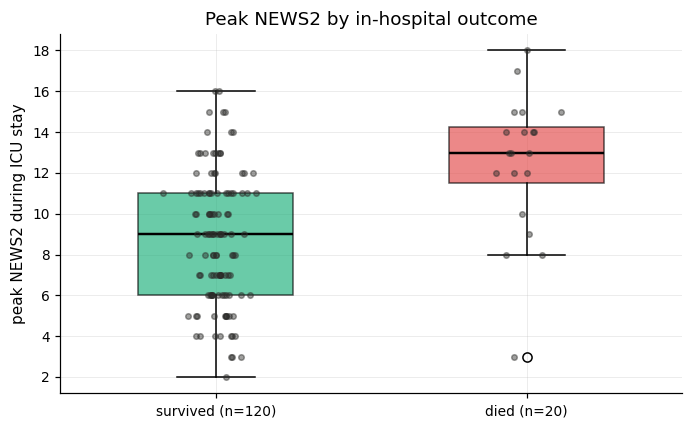

                      count   mean   50%   max
hospital_expire_flag                          
0                     120.0   8.75   9.0  16.0
1                      20.0  12.45  13.0  18.0


In [26]:
# Does NEWS2 separate patients who died from those who survived? (small n - indicative only)
stay_max = ff.groupby("stay_id").news2.max().rename("max_news2").reset_index()
stay_max = stay_max.merge(icu_out[["stay_id", "hospital_expire_flag"]], on="stay_id", how="left")

fig, ax = plt.subplots(figsize=(6.4, 4))
data = [stay_max[stay_max.hospital_expire_flag == 0].max_news2,
        stay_max[stay_max.hospital_expire_flag == 1].max_news2]
bp = ax.boxplot(data, labels=[f"survived (n={len(data[0])})", f"died (n={len(data[1])})"],
                patch_artist=True, widths=0.5, medianprops=dict(color="black", lw=1.6))
for patch, c in zip(bp["boxes"], [OK, BAD], strict=False):
    patch.set_facecolor(c); patch.set_alpha(0.65)
for i, d in enumerate(data, start=1):
    ax.scatter(np.random.normal(i, 0.045, len(d)), d, s=13, color="#2c2c2a", alpha=0.45, zorder=3)
ax.set_ylabel("peak NEWS2 during ICU stay")
ax.set_title("Peak NEWS2 by in-hospital outcome")
save(fig, "09_news2_vs_outcome"); plt.show()

print(stay_max.groupby("hospital_expire_flag").max_news2.describe()[["count","mean","50%","max"]].round(2).to_string())

**Interpretation — the most encouraging result in this notebook.**

NEWS2 is computable today, with no synthetic data and no model training. A median of 6 of 7 components is
available per patient-hour after carry-forward. 110 of 140 stays cross the medium-escalation threshold
(≥5) and 68 cross the high threshold (≥7).

This matters for three reasons:

1. **The Early Warning & Alert System deliverable has a working implementation from day one**, independent
   of whether any machine-learning model succeeds. That de-risks the project substantially.
2. **It gives us the baseline that makes the ML work honest.** Any learned deterioration model must be
   compared against NEWS2 on identical folds. Beating a strong clinical rule is the real bar.
3. **The boxplot hints at separation** between survivors and non-survivors, though with 20 deaths this is
   indicative only and must be reported with confidence intervals, never as a point estimate.

One caveat worth stating: NEWS2 was designed for general-ward patients, not ICU patients, so scores skew
high here by construction. It remains the right baseline, but the alert threshold will need recalibration
to the ICU population rather than using the ward-derived cut-offs directly.

---
## 8. Laboratory results

Labs are the second time-series modality and drive several organ-dysfunction components of severity
scores.

In [27]:
labevents  = read_mimic("hosp", "labevents")
d_labitems = read_mimic("hosp", "d_labitems")
labevents["charttime"] = pd.to_datetime(labevents.charttime)
lab = labevents.merge(d_labitems, on="itemid", how="left")

print(f"Lab results   : {len(labevents):,}")
print(f"Distinct assays: {labevents.itemid.nunique()}")
print(f"Patient coverage: {labevents.subject_id.nunique()} / 100")
print(f"Flagged abnormal: {(labevents.flag == 'abnormal').sum():,} ({pct((labevents.flag=='abnormal').sum(), len(labevents))}%)")

Lab results   : 107,727
Distinct assays: 498
Patient coverage: 100 / 100
Flagged abnormal: 40,275 (37.4%)


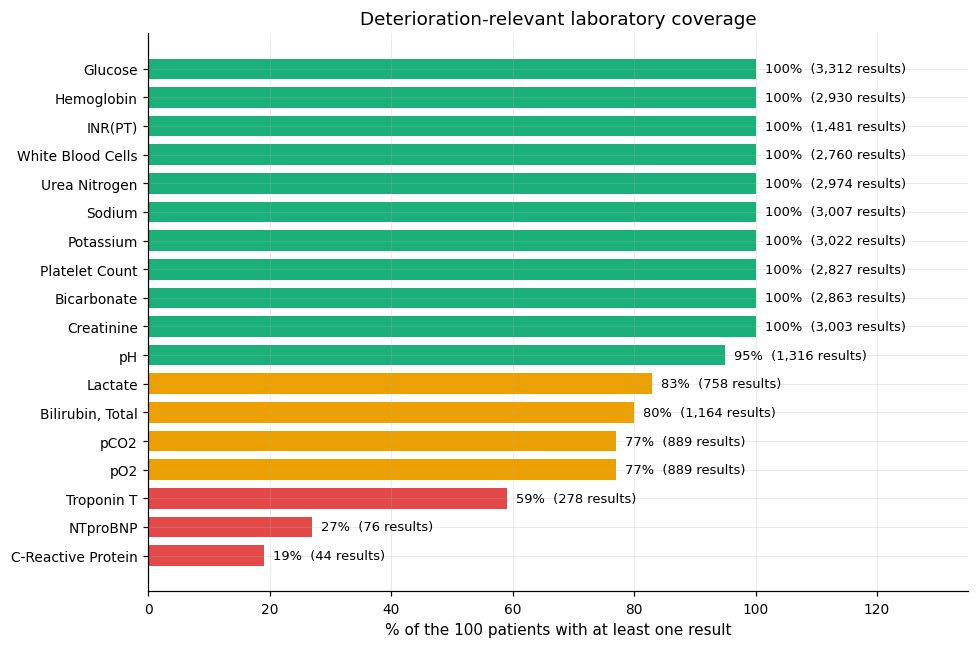

,n,patients,patient_coverage_pct,median
label,,,,
Bicarbonate,2863,100,100.0,25.00
INR(PT),1481,100,100.0,1.30
White Blood Cells,2760,100,100.0,9.30
Urea Nitrogen,2974,100,100.0,19.00
Sodium,3007,100,100.0,138.00
Potassium,3022,100,100.0,4.10
Platelet Count,2827,100,100.0,190.00
Hemoglobin,2930,100,100.0,9.80
Glucose,3312,100,100.0,122.00


In [28]:
# Labs that matter for deterioration, sepsis and organ dysfunction
KEY_LABS = ["Lactate", "Creatinine", "White Blood Cells", "Platelet Count", "Bilirubin, Total",
            "pH", "Hemoglobin", "Sodium", "Potassium", "Urea Nitrogen", "Bicarbonate",
            "Troponin T", "NTproBNP", "C-Reactive Protein", "pO2", "pCO2", "INR(PT)", "Glucose"]

kl = (lab[lab.label.isin(KEY_LABS)]
        .groupby("label")
        .agg(n=("valuenum", "size"), patients=("subject_id", "nunique"), median=("valuenum", "median"))
        .sort_values("patients", ascending=False))
kl["patient_coverage_pct"] = kl.patients.map(lambda p: pct(p, 100))

fig, ax = plt.subplots(figsize=(9, 6))
k = kl.sort_values("patient_coverage_pct")
cols = [OK if c >= 90 else WARN if c >= 60 else BAD for c in k.patient_coverage_pct]
ax.barh(k.index, k.patient_coverage_pct, color=cols, height=0.72)
for y, (c, n) in enumerate(zip(k.patient_coverage_pct, k.n, strict=False)):
    ax.text(c + 1.5, y, f"{c:.0f}%  ({n:,} results)", va="center", fontsize=8.5)
ax.set_xlim(0, 135); ax.set_xlabel("% of the 100 patients with at least one result")
ax.set_title("Deterioration-relevant laboratory coverage")
save(fig, "10_labs"); plt.show()

kl[["n", "patients", "patient_coverage_pct", "median"]].round(2)

**Interpretation.** Lab coverage is genuinely strong and is the least problematic input source in the
project. The core chemistry and haematology panels reach 100% of patients, which means every
organ-dysfunction component of SOFA that depends on labs — platelets, bilirubin, creatinine — is
computable for the whole cohort.

Lactate at 83% is important: it is the key sepsis and shock marker, and having it for most patients makes
the sepsis pathway viable.

The sparse ones — NTproBNP at 27%, C-reactive protein at 19% — are ordered only when clinically suspected.
As with arterial lines, **their absence is informative and should be modelled as a feature rather than
imputed.** Ordering behaviour encodes clinician suspicion, which is real predictive signal.

---
## 9. Severity scores and sepsis — feasibility check

The plan calls for reusing the `MIT-LCP/mimic-code` derived-concept SQL (SOFA, SAPS-II, OASIS, Sepsis-3).
Those scripts assume the full MIMIC-IV release. This section verifies that their required inputs actually
exist in the demo subset, before we invest in wiring the pipeline.

In [29]:
inputevents     = read_mimic("icu", "inputevents")
procedureevents = read_mimic("icu", "procedureevents")
outputevents    = read_mimic("icu", "outputevents")
prescriptions   = read_mimic("hosp", "prescriptions")
microbiology    = read_mimic("hosp", "microbiologyevents")

VASO = {221906: "Norepinephrine", 221289: "Epinephrine", 221662: "Dopamine",
        221653: "Dobutamine", 221749: "Phenylephrine", 222315: "Vasopressin",
        221986: "Milrinone"}
vaso_rows = [{"agent": n,
              "administrations": int((inputevents.itemid == i).sum()),
              "stays": int(inputevents[inputevents.itemid == i].stay_id.nunique())}
             for i, n in VASO.items()]
vaso = pd.DataFrame(vaso_rows).sort_values("stays", ascending=False)

any_vaso_stays = inputevents[inputevents.itemid.isin(VASO)].stay_id.nunique()
vent_stays     = procedureevents[procedureevents.itemid.isin([225792, 225794])].stay_id.nunique()
urine_stays    = outputevents.stay_id.nunique()

print(f"Stays receiving any vasopressor : {any_vaso_stays} / {N_STAYS}")
print(f"Stays with documented ventilation: {vent_stays} / {N_STAYS}")
print(f"Stays with urine output recorded : {urine_stays} / {N_STAYS}")
vaso

Stays receiving any vasopressor : 52 / 140
Stays with documented ventilation: 66 / 140
Stays with urine output recorded : 137 / 140


,agent,administrations,stays
0,Norepinephrine,947,33
4,Phenylephrine,625,33
5,Vasopressin,55,9
2,Dopamine,28,5
1,Epinephrine,36,4
3,Dobutamine,44,4
6,Milrinone,15,2


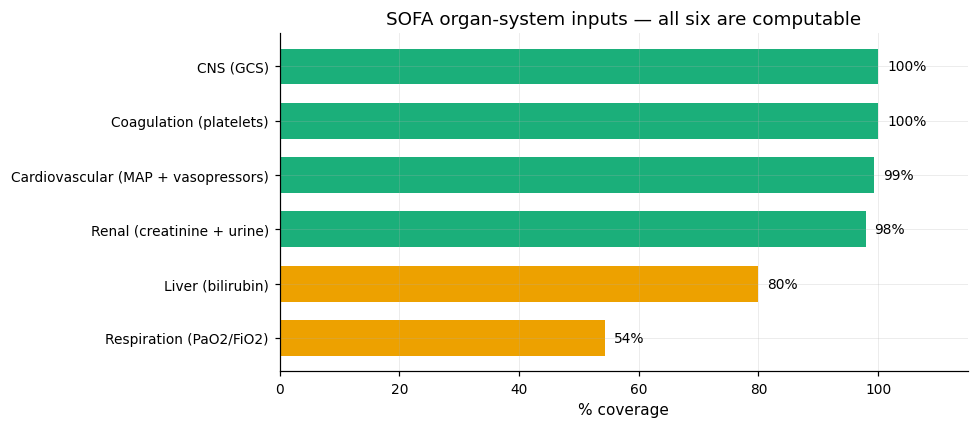

In [30]:
# SOFA component feasibility - each of the six organ systems
sofa_inputs = {
    "Respiration (PaO2/FiO2)": pct(chartevents[chartevents.itemid == 223835].stay_id.nunique(), N_STAYS),
    "Coagulation (platelets)": pct(lab[lab.label == "Platelet Count"].subject_id.nunique(), 100),
    "Liver (bilirubin)":       pct(lab[lab.label == "Bilirubin, Total"].subject_id.nunique(), 100),
    "Cardiovascular (MAP + vasopressors)": pct(grid["map"].notna().groupby(grid.stay_id).any().sum(), N_STAYS),
    "CNS (GCS)":               pct(chartevents[chartevents.itemid == 220739].stay_id.nunique(), N_STAYS),
    "Renal (creatinine + urine)": pct(urine_stays, N_STAYS),
}
s = pd.Series(sofa_inputs).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(s.index, s.values, color=[OK if v >= 90 else WARN if v >= 50 else BAD for v in s.values], height=0.66)
for y, v in enumerate(s.values):
    ax.text(v + 1.5, y, f"{v:.0f}%", va="center", fontsize=9)
ax.set_xlim(0, 115); ax.set_xlabel("% coverage")
ax.set_title("SOFA organ-system inputs — all six are computable")
save(fig, "11_sofa_feasibility"); plt.show()

In [31]:
# Sepsis-3 requires "suspicion of infection" = antibiotic order + culture, within a time window
ABX = ["vancomycin", "ceftriaxone", "cefepime", "piperacillin", "meropenem", "metronidazole",
       "levofloxacin", "ciprofloxacin", "azithromycin", "ampicillin", "gentamicin", "linezolid",
       "cefazolin", "aztreonam", "daptomycin", "clindamycin"]
abx = prescriptions[prescriptions.drug.str.lower().str.contains("|".join(ABX), na=False)]

print("Sepsis-3 'suspicion of infection' ingredients:")
print(f"  Antibiotic orders  : {len(abx):,} across {abx.hadm_id.nunique()} admissions, {abx.subject_id.nunique()} patients")
print(f"  Microbiology tests : {len(microbiology):,} across {microbiology.subject_id.nunique()} patients")
print(f"  Positive isolates  : {microbiology.org_name.notna().sum():,}")
print(f"\n  Admissions with BOTH an antibiotic order and a culture: "
      f"{len(set(abx.hadm_id.dropna()) & set(microbiology.hadm_id.dropna()))}")

Sepsis-3 'suspicion of infection' ingredients:
  Antibiotic orders  : 812 across 149 admissions, 76 patients
  Microbiology tests : 2,899 across 97 patients
  Positive isolates  : 1,258

  Admissions with BOTH an antibiotic order and a culture: 121


**Interpretation.** All six SOFA organ systems are computable, so `sofa.sql`, `sapsii.sql` and `oasis.sql`
from `mimic-code` should run against the demo with only minor patching. That is a significant saving —
these scripts encode years of careful clinical definition work and reimplementing them would be both slow
and error-prone.

Sepsis-3 is also reachable: 132 admissions have both an antibiotic order and a culture, satisfying the
suspicion-of-infection criterion, and SOFA supplies the organ-dysfunction criterion.

Two cautions carried into implementation:
- Vasopressor exposure is concentrated — norepinephrine in 33 stays, phenylephrine in 33, and the rest in
  single digits. Any cardiovascular SOFA component above 2 will be rare, so the score will compress toward
  the low end relative to a full-scale cohort.
- Renal replacement therapy appears in only 9 stays, so `rrt`/`crrt` concepts will be near-empty and
  should be expected to fail or return trivially. Plan for the concept runner to tolerate this rather
  than treating it as a pipeline error.

---
## 10. ECG — the diagnostic waveform modality

The second dataset supplies 12-lead diagnostic ECGs. The critical question is whether they link to the
clinical cohort, because an unlinked waveform set cannot support multimodal fusion.

In [32]:
ecg_records = pd.read_csv(ECG / "record_list.csv")
ecg_records["ecg_time"] = pd.to_datetime(ecg_records.ecg_time)
demo_ids = pd.read_csv(MIMIC / "demo_subject_id.csv").iloc[:, 0]

overlap = set(ecg_records.subject_id) & set(demo_ids)
print(f"ECG studies        : {len(ecg_records):,}")
print(f"ECG patients       : {ecg_records.subject_id.nunique()}")
print(f"Clinical demo patients: {demo_ids.nunique()}")
print(f"LINKABLE patients  : {len(overlap)}  ({pct(len(overlap), demo_ids.nunique())}% of the clinical cohort)")
print(f"Studies per patient: median {ecg_records.groupby('subject_id').size().median():.0f}, "
      f"max {ecg_records.groupby('subject_id').size().max()}")

ECG studies        : 659
ECG patients       : 92
Clinical demo patients: 100
LINKABLE patients  : 92  (92.0% of the clinical cohort)
Studies per patient: median 5, max 52


In [33]:
def read_wfdb_header(hea_path):
    '''Minimal WFDB header parser - avoids a wfdb dependency.'''
    lines = [l for l in Path(hea_path).read_text().splitlines() if l and not l.startswith("#")]
    name, n_sig, fs, n_samp = lines[0].split()[:4]
    leads = [l.split()[-1] for l in lines[1:]]
    return {"n_sig": int(n_sig), "fs": float(fs), "n_samp": int(n_samp), "leads": leads}

def read_wfdb_signal(dat_path, n_sig, gain=200.0):
    '''Read WFDB format-16 (int16, little-endian, lead-interleaved) into mV.'''
    raw = np.fromfile(dat_path, dtype="<i2")
    return raw.reshape(-1, n_sig) / gain

sample_hea = ECG / "files/p10005866/s100986017/100986017.hea"
sample_dat = ECG / "files/p10005866/s100986017/100986017.dat"
hdr = read_wfdb_header(sample_hea)
sig = read_wfdb_signal(sample_dat, hdr["n_sig"])
print(hdr)
print(f"Signal array: {sig.shape}  ->  {hdr['n_samp']/hdr['fs']:.0f} seconds at {hdr['fs']:.0f} Hz")

{'n_sig': 12, 'fs': 500.0, 'n_samp': 5000, 'leads': ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']}
Signal array: (5000, 12)  ->  10 seconds at 500 Hz


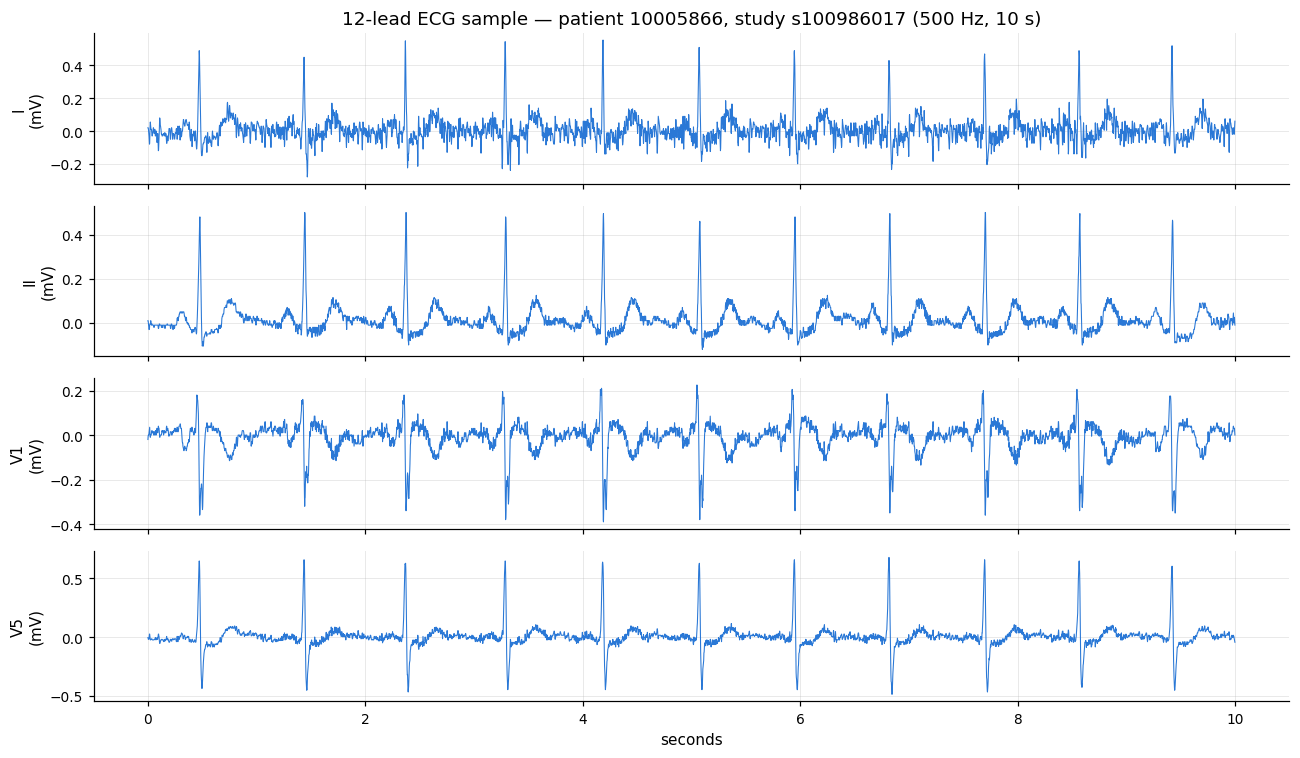

In [34]:
t = np.arange(hdr["n_samp"]) / hdr["fs"]
fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax, lead_name in zip(axes, ["I", "II", "V1", "V5"], strict=False):
    idx = hdr["leads"].index(lead_name)
    ax.plot(t, sig[:, idx], lw=0.7, color=ACCENT)
    ax.set_ylabel(f"{lead_name}\n(mV)")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("seconds")
axes[0].set_title(f"12-lead ECG sample — patient 10005866, study s100986017 "
                  f"({hdr['fs']:.0f} Hz, {hdr['n_samp']/hdr['fs']:.0f} s)")
save(fig, "12_ecg_sample"); plt.show()

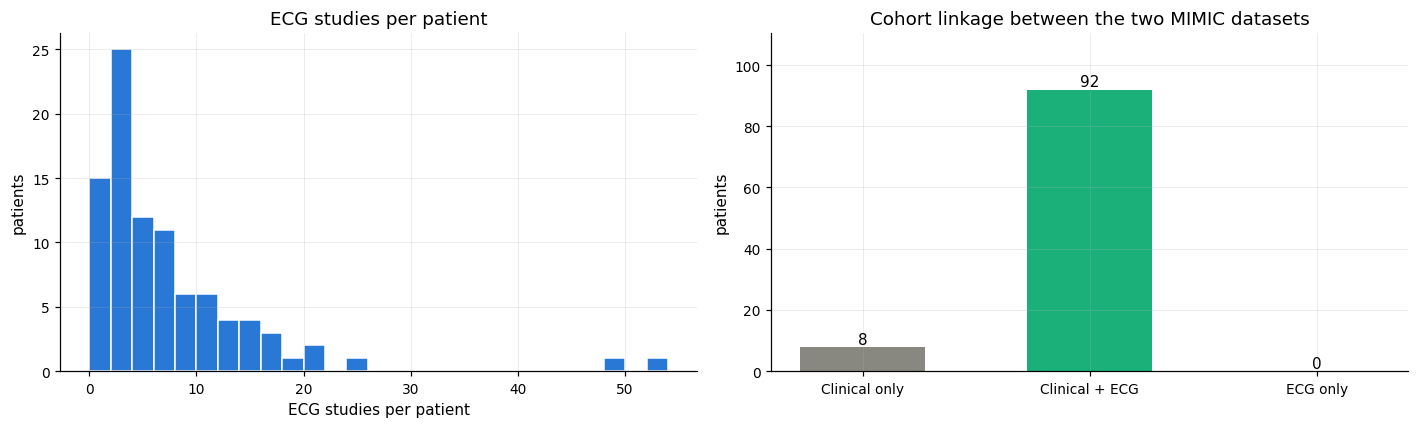

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
per_pt = ecg_records.groupby("subject_id").size()
ax.hist(per_pt, bins=np.arange(0, per_pt.max() + 3, 2), color=ACCENT, edgecolor="white")
ax.set_xlabel("ECG studies per patient"); ax.set_ylabel("patients")
ax.set_title("ECG studies per patient")

ax = axes[1]
venn = pd.Series({
    "Clinical only":     demo_ids.nunique() - len(overlap),
    "Clinical + ECG":    len(overlap),
    "ECG only":          ecg_records.subject_id.nunique() - len(overlap),
})
ax.bar(venn.index, venn.values, color=[NEUTRAL, OK, WARN], width=0.55)
for i, v in enumerate(venn.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=10)
ax.set_ylabel("patients"); ax.set_ylim(0, venn.max() * 1.2)
ax.set_title("Cohort linkage between the two MIMIC datasets")

save(fig, "13_ecg_linkage"); plt.show()

**Interpretation.** The linkage is the headline: **92 of the 100 clinical-demo patients have ECGs**, joining
cleanly on `subject_id`. This is real multimodal data on a shared cohort, not two unrelated datasets
presented side by side — which makes the multimodal fusion claim in the project defensible.

Two limits to state clearly:

- These are **10-second diagnostic snapshots at 500 Hz, not continuous telemetry.** They are episodic
  evidence, not a monitoring stream. In the architecture they belong as a feature source (rate, rhythm,
  QRS duration, QTc) joined to the nearest patient-hour, not as a streaming input.
- The demo omits `machine_measurements.csv`, which in the full release carries the cardiologist and machine
  diagnostic statements. So there are **no ECG labels** — any rhythm classification must be derived by
  signal processing (for example with `neurokit2`), not learned from supervision.

Reading these files needed no external dependency: WFDB format-16 is a plain interleaved int16 array,
parsed above in about ten lines.

---
## 11. Wearable device dataset

The third dataset supplies the wearable modality. The questions are: what signals, at what rate, from
whom, and can they stand in for post-discharge patient monitoring?

In [36]:
subject_info = pd.read_csv(WEAR / "subject-info.csv", encoding="latin-1")
print(f"Participants: {len(subject_info)}")
print(subject_info.head(6).to_string(index=False))

print("\nData dictionary:")
print(pd.read_csv(WEAR / "Data_Dictionary.csv", encoding="latin-1").to_string(index=False))

Participants: 46
Info  Gender Age Height (cm) Weight (kg) Does physical activity regularly? Protocol Stress Inducement Aerobic Exercise Anaerobic Exercise
  S01      m  21         192          84                               Yes       V1               Yes              Yes            Yes****
  S02      m  20         185          95                                No       V1           Yes****              Yes                Yes
  S03      m  20         175          62                               Yes       V1               Yes           Yes***                Yes
  S04      m  21         174          70                               Yes       V1               Yes              Yes                Yes
  S05      m  21         173          72                               Yes       V1               Yes              Yes                Yes
  S06      m  21         172          70                               Yes       V1               Yes              Yes             Yes***

Data dictionary:

In [37]:
WD = WEAR / "Wearable_Dataset"

def read_e4(path):
    '''Empatica E4 file: row 0 = session start (UTC), row 1 = sampling rate (Hz), rest = samples.'''
    if not path.exists() or path.stat().st_size == 0:
        return None, None, None
    try:
        d = pd.read_csv(path, header=None)
    except Exception:
        return None, None, None
    if len(d) < 3:
        return None, None, None
    t0   = pd.to_datetime(d.iloc[0, 0])          # row 0: session start, UTC datetime string
    fs   = float(d.iloc[1, 0])                    # row 1: sampling rate in Hz
    vals = d.iloc[2:].reset_index(drop=True).astype(float)
    return t0, fs, vals

records = []
for activity in ["STRESS", "AEROBIC", "ANAEROBIC"]:
    for session in sorted(p for p in os.listdir(WD / activity) if not p.startswith(".")):
        rec = {"activity": activity, "session": session}
        for sig_name in ["HR", "EDA", "TEMP", "BVP", "ACC"]:
            _, fs, vals = read_e4(WD / activity / session / f"{sig_name}.csv")
            rec[f"{sig_name}_fs"] = fs
            rec[f"{sig_name}_min"] = round(len(vals) / fs / 60, 2) if vals is not None else np.nan
        ibi = WD / activity / session / "IBI.csv"
        rec["IBI_beats"] = (len(pd.read_csv(ibi, header=None)) - 1) if ibi.exists() and ibi.stat().st_size else 0
        tags = WD / activity / session / "tags.csv"
        rec["event_tags"] = len(pd.read_csv(tags, header=None)) if tags.exists() and tags.stat().st_size else 0
        records.append(rec)

wear = pd.DataFrame(records)
print(f"\n{len(wear)} sessions. Total recording: {wear.HR_min.sum()/60:.1f} hours of HR, "
      f"{wear.BVP_min.sum()/60:.1f} hours of 64 Hz BVP.")
print("\nSampling rates found:",
      {c.replace('_fs',''): sorted(set(wear[c].dropna())) for c in wear.columns if c.endswith('_fs')})

wear.groupby("activity").agg(
    sessions=("session", "size"),
    mean_minutes=("HR_min", "mean"),
    total_hours=("HR_min", lambda s: round(s.sum() / 60, 1)),
    mean_event_tags=("event_tags", "mean"),
    mean_ibi_beats=("IBI_beats", "mean"),
).round(2)


100 sessions. Total recording: 57.8 hours of HR, 58.0 hours of 64 Hz BVP.

Sampling rates found: {'HR': [1.0], 'EDA': [4.0], 'TEMP': [4.0], 'BVP': [64.0], 'ACC': [32.0]}


,sessions,mean_minutes,total_hours,mean_event_tags,mean_ibi_beats
activity,,,,,
AEROBIC,31,35.24,18.2,9.65,818.55
ANAEROBIC,32,25.91,13.8,8.41,557.81
STRESS,37,41.74,25.7,10.70,1841.14


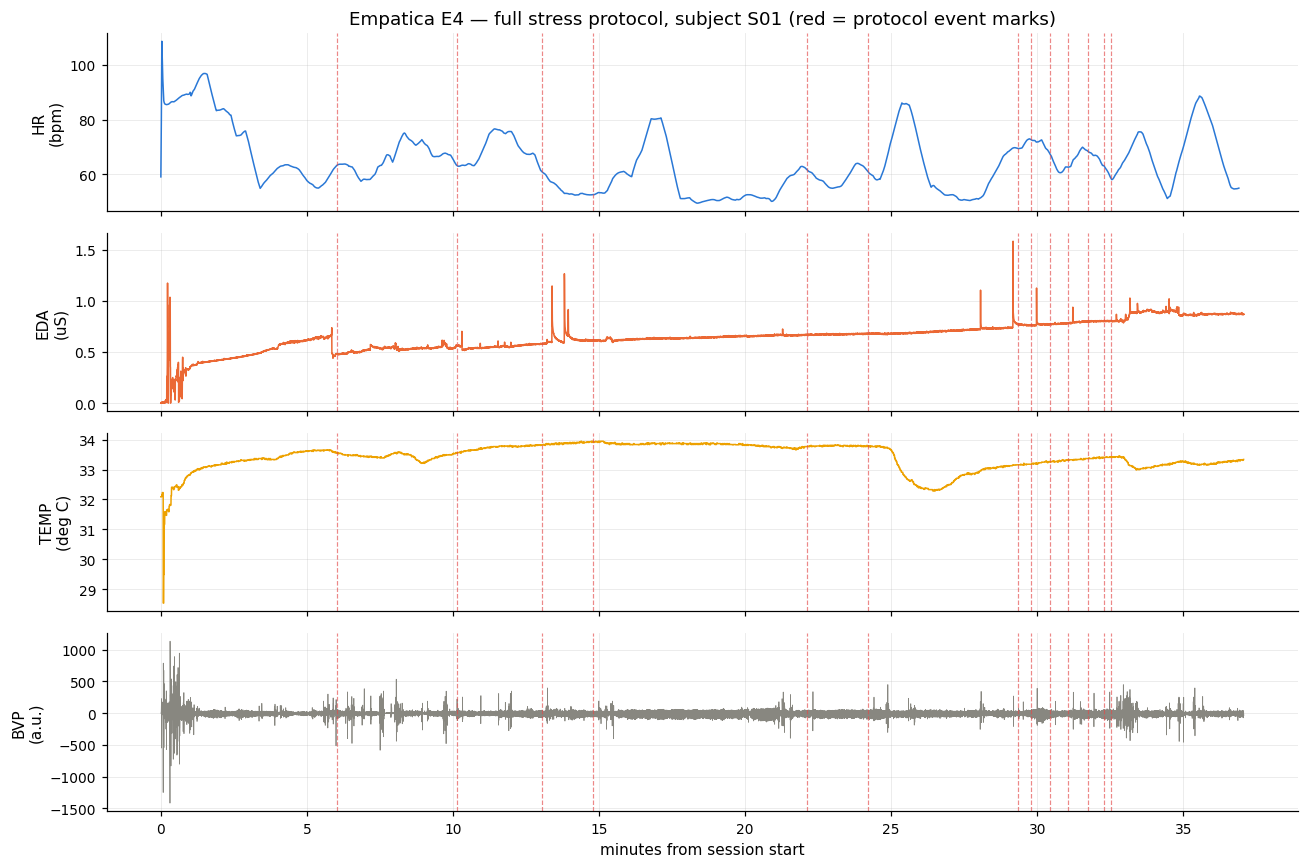

In [38]:
# Plot one full stress session across all four physiological channels
sess = WD / "STRESS" / "S01"
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, (sig_name, unit, colour) in zip(axes, [("HR", "bpm", ACCENT), ("EDA", "uS", "#eb6834"),
                                               ("TEMP", "deg C", "#eda100"), ("BVP", "a.u.", NEUTRAL)], strict=False):
    _, fs, vals = read_e4(sess / f"{sig_name}.csv")
    t = np.arange(len(vals)) / fs / 60
    ax.plot(t, vals.iloc[:, 0], lw=0.5 if sig_name == "BVP" else 1.0, color=colour)
    ax.set_ylabel(f"{sig_name}\n({unit})")

tags  = pd.to_datetime(pd.read_csv(sess / "tags.csv", header=None)[0])
t0, _, _ = read_e4(sess / "HR.csv")
for tg in tags:
    for ax in axes:
        ax.axvline((tg - t0).total_seconds() / 60, color=BAD, ls="--", lw=0.8, alpha=0.65)

axes[-1].set_xlabel("minutes from session start")
axes[0].set_title("Empatica E4 — full stress protocol, subject S01 (red = protocol event marks)")
save(fig, "14_wearable_session"); plt.show()

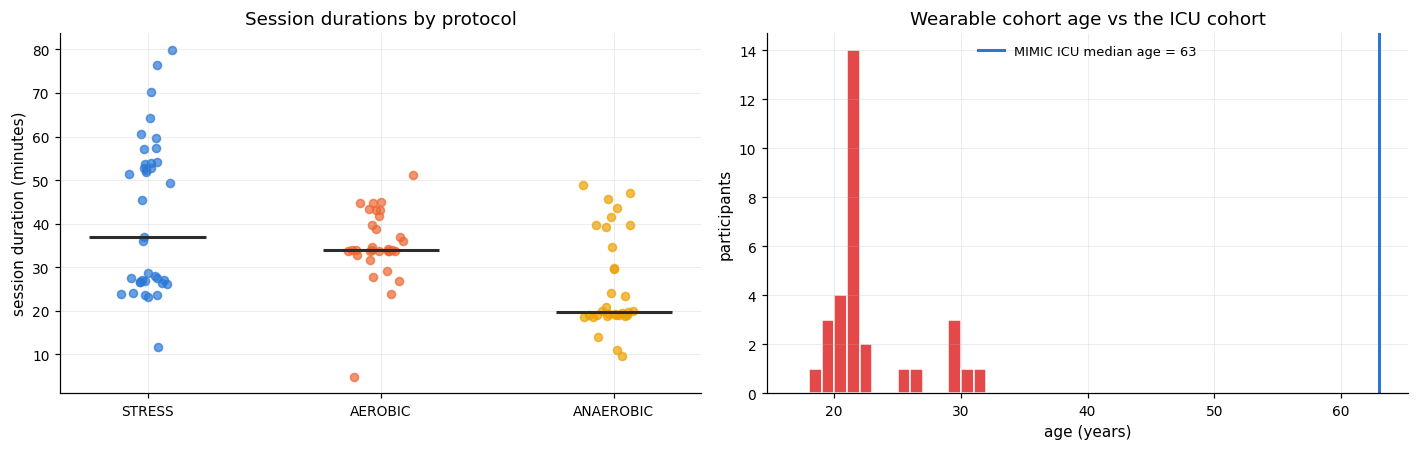

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
for i, act in enumerate(["STRESS", "AEROBIC", "ANAEROBIC"]):
    d = wear[wear.activity == act].HR_min.dropna()
    ax.scatter(np.random.normal(i, 0.07, len(d)), d, s=28, alpha=0.7,
               color=[ACCENT, "#eb6834", "#eda100"][i])
    ax.hlines(d.median(), i - 0.25, i + 0.25, color="#2c2c2a", lw=2)
ax.set_xticks(range(3)); ax.set_xticklabels(["STRESS", "AEROBIC", "ANAEROBIC"])
ax.set_ylabel("session duration (minutes)")
ax.set_title("Session durations by protocol")

ax = axes[1]
ages = pd.to_numeric(subject_info["Age"], errors="coerce").dropna()
ax.hist(ages, bins=np.arange(17, 40, 1), color=BAD, edgecolor="white")
ax.axvline(patients.anchor_age.median(), color=ACCENT, lw=2,
           label=f"MIMIC ICU median age = {patients.anchor_age.median():.0f}")
ax.set_xlabel("age (years)"); ax.set_ylabel("participants")
ax.set_title("Wearable cohort age vs the ICU cohort")
ax.legend(fontsize=8.5)

save(fig, "15_wearable_summary"); plt.show()

**Interpretation — technically excellent, clinically unrepresentative.**

The signal quality is exactly what the platform needs: BVP at 64 Hz, accelerometer at 32 Hz, EDA and skin
temperature at 4 Hz, derived HR at 1 Hz, plus inter-beat intervals that permit proper heart-rate-variability
computation. About 58 hours across 100 sessions, with protocol event marks giving labelled physiological
state transitions. That is a genuine high-frequency IoT stream to build and test the ingestion pipeline on.

But the second panel states the problem plainly. **These are healthy volunteers with a median age around 21,
against an ICU cohort with a median age of 63.** No participant is ill. There is no patient identifier that
links to MIMIC, and there cannot be — different study, different continent, different decade.

Consequences for the build:

- The wearable data is a **transport and signal-processing testbed**, not a clinical training set. It proves
  the pipeline handles 64 Hz multi-channel streams, computes HRV correctly, and survives session gaps.
- Any *post-discharge deterioration* scenario requires conditioning these signals on a target clinical
  trajectory — shifting the HR baseline, suppressing HRV, injecting desaturation events. That is synthetic
  augmentation and must be documented as such wherever results are reported.
- The known data-quality issues in `data_constraints.txt` must be honoured in code: subject `f07` has invalid
  PPG and temperature (the sensor dock was never removed), `S02` contains duplicated signal blocks, and
  `f14`, `S11`, `S16` are each split across two files after Bluetooth dropouts. These are exactly the fault
  conditions a production ingestion layer should handle, so they are useful test fixtures.

---
## 12. The resolution gap

Placing every source on one axis makes the central architectural challenge visible: the data spans seven
orders of magnitude in sampling rate, and the clinically richest source is the slowest.

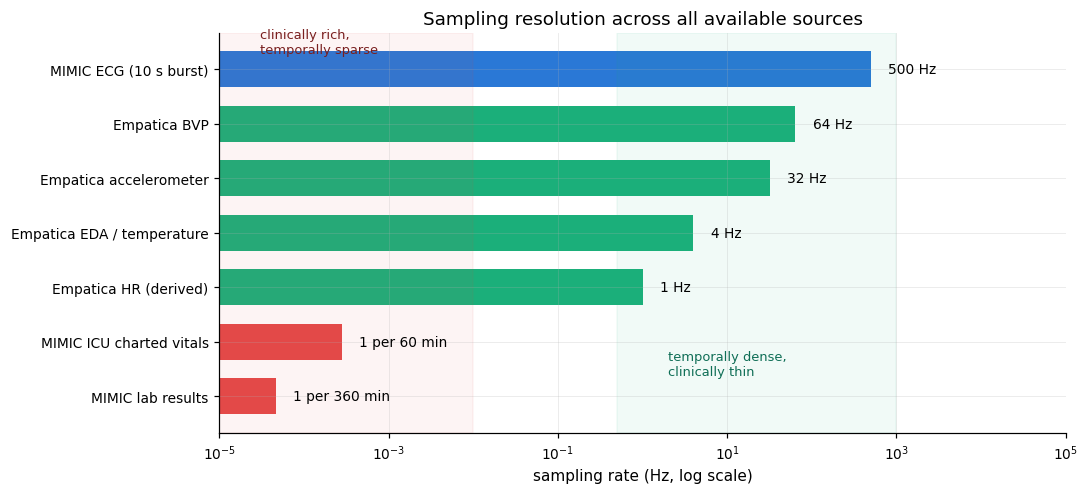

In [40]:
sources = pd.DataFrame([
    ("MIMIC ICU charted vitals",  1/3600,    "clinical",  BAD),
    ("MIMIC lab results",         1/(6*3600),"clinical",  BAD),
    ("Empatica HR (derived)",     1.0,       "wearable",  OK),
    ("Empatica EDA / temperature",4.0,       "wearable",  OK),
    ("Empatica accelerometer",    32.0,      "wearable",  OK),
    ("Empatica BVP",              64.0,      "wearable",  OK),
    ("MIMIC ECG (10 s burst)",    500.0,     "waveform",  ACCENT),
], columns=["source", "hz", "kind", "colour"]).sort_values("hz")

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.barh(sources.source, sources.hz, color=sources.colour, height=0.66)
ax.set_xscale("log")
ax.set_xlabel("sampling rate (Hz, log scale)")
ax.set_title("Sampling resolution across all available sources")
for y, (h, s) in enumerate(zip(sources.hz, sources.source, strict=False)):
    lbl = f"{h:.0f} Hz" if h >= 1 else f"1 per {1/h/60:.0f} min"
    ax.text(h * 1.6, y, lbl, va="center", fontsize=9)
ax.set_xlim(1e-5, 1e5)
ax.axvspan(1e-5, 1e-2, color=BAD, alpha=0.06)
ax.text(3e-5, 6.3, "clinically rich,\ntemporally sparse", fontsize=8.5, color="#791f1f")
ax.axvspan(0.5, 1e3, color=OK, alpha=0.06)
ax.text(2, 0.4, "temporally dense,\nclinically thin", fontsize=8.5, color="#0f6e56")
save(fig, "16_resolution_gap"); plt.show()

**Interpretation.** The two ends of this chart are inversely related in value. The sources that carry
clinical meaning — vitals tied to real outcomes, labs, diagnoses — arrive hourly at best. The sources that
stream continuously carry no illness at all.

This is the gap the architecture has to bridge, and it drives the single most important design decision in
the project: **one stream contract, many producers.** A single `Observation` message schema, satisfied
equally by the ICU replay, the wearable replay and the live smartwatch, means the alerting and agent layers
never need to know which source they are consuming. Sources can then be swapped, mixed or upgraded — including
to full MIMIC-IV later — without touching the downstream engine.

---
## 13. Coverage verdict and gap register

Consolidating everything above against the six declared input sources and the eleven deliverables.

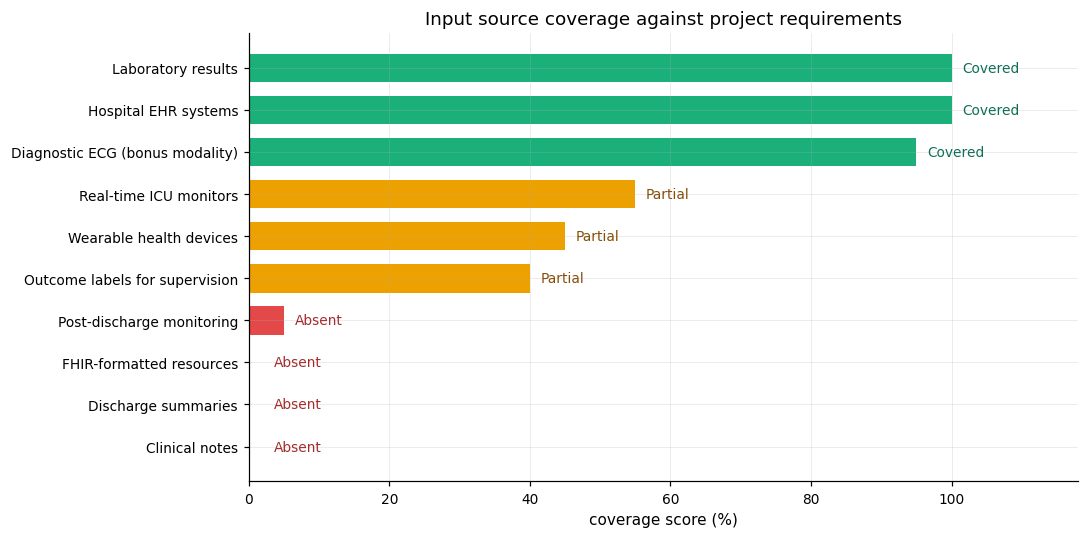

,input_source,status,evidence
0,Hospital EHR systems,Covered,"275 admissions, 4,506 coded diagnoses, 18,087 prescriptions, 1,190 transfers"
1,Laboratory results,Covered,"107,727 results across 498 assays, 100% patient coverage"
2,Diagnostic ECG (bonus modality),Covered,"659 studies, 12-lead 500 Hz, 92/100 patients linkable"
3,Real-time ICU monitors,Partial,Vitals present for 100% of stays but charted hourly - not a bedside monitor stream
4,Wearable health devices,Partial,"58 h of high-rate signal, but healthy volunteers (median age ~21), no patient link"
5,Outcome labels for supervision,Partial,"20 ICU deaths, 53 30-day readmissions - viable per-hour, underpowered per-stay"
6,Clinical notes,Absent,MIMIC-IV demo excludes the note module entirely
7,Discharge summaries,Absent,Only the structured discharge_location code exists
8,Post-discharge monitoring,Absent,"2,964 sparse outpatient vitals only - no home time series"
9,FHIR-formatted resources,Absent,Flat CSVs; a mapping layer must be built


In [41]:
coverage = pd.DataFrame([
    ("Hospital EHR systems", "Covered", 100,
     f"{len(admissions)} admissions, {len(read_mimic('hosp','diagnoses_icd')):,} coded diagnoses, "
     f"{len(prescriptions):,} prescriptions, {len(transfers):,} transfers"),
    ("Laboratory results", "Covered", 100,
     f"{len(labevents):,} results across {labevents.itemid.nunique()} assays, 100% patient coverage"),
    ("Diagnostic ECG (bonus modality)", "Covered", 95,
     f"{len(ecg_records)} studies, 12-lead 500 Hz, {len(overlap)}/100 patients linkable"),
    ("Real-time ICU monitors", "Partial", 55,
     "Vitals present for 100% of stays but charted hourly - not a bedside monitor stream"),
    ("Wearable health devices", "Partial", 45,
     f"{wear.HR_min.sum()/60:.0f} h of high-rate signal, but healthy volunteers (median age ~21), no patient link"),
    ("Outcome labels for supervision", "Partial", 40,
     f"{icu_deaths} ICU deaths, {readmit[30]} 30-day readmissions - viable per-hour, underpowered per-stay"),
    ("Clinical notes", "Absent", 0,
     "MIMIC-IV demo excludes the note module entirely"),
    ("Discharge summaries", "Absent", 0,
     "Only the structured discharge_location code exists"),
    ("Post-discharge monitoring", "Absent", 5,
     f"{len(read_mimic('hosp','omr')):,} sparse outpatient vitals only - no home time series"),
    ("FHIR-formatted resources", "Absent", 0,
     "Flat CSVs; a mapping layer must be built"),
], columns=["input_source", "status", "score", "evidence"])

fig, ax = plt.subplots(figsize=(10, 5))
cmap = {"Covered": OK, "Partial": WARN, "Absent": BAD}
c = coverage.sort_values("score")
ax.barh(c.input_source, c.score, color=[cmap[s] for s in c.status], height=0.68)
for y, (s, st) in enumerate(zip(c.score, c.status, strict=False)):
    ax.text(max(s, 2) + 1.5, y, st, va="center", fontsize=9,
            color={"Covered": "#0f6e56", "Partial": "#854f0b", "Absent": "#a32d2d"}[st])
ax.set_xlim(0, 118); ax.set_xlabel("coverage score (%)")
ax.set_title("Input source coverage against project requirements")
save(fig, "17_coverage_verdict"); plt.show()

pd.set_option("display.max_colwidth", 110)
coverage[["input_source", "status", "evidence"]]

In [42]:
gaps = pd.DataFrame([
    ("Clinical notes & discharge summaries", "Blocks RAG summarisation deliverable",
     "LLM-generate from structured MIMIC facts, emitting a fact ledger that maps every generated "
     "sentence back to its source rows. This yields mechanical faithfulness evaluation that real "
     "notes could not provide."),
    ("Sub-hourly ICU streams", "Blocks the real-time monitoring claim",
     "Time-compressed replay of the hourly grid (1 h -> 1 s). Label it as replay in all reporting."),
    ("Wearables on unwell patients", "Blocks post-discharge deterioration scenarios",
     "Condition Empatica segments on target NEWS2 trajectories. Document as synthetic augmentation."),
    ("Live post-discharge telemetry", "Blocks the Smart Hospital connectivity claim",
     "Android/Wear OS smartwatch over MQTT via an edge agent. The one genuinely real-time source."),
    ("FHIR resources", "Blocks the interoperability deliverable",
     "Build a mapping layer. Shape the stream contract as a FHIR Observation from the outset so this "
     "is a projection rather than a translation."),
    ("Alert ground truth", "Blocks alert-quality evaluation",
     "Derive from vasopressor and ventilation initiation timestamps, confirmed present in section 9."),
    ("Cohort scale", "Caps all clinical claims",
     "Unresolvable without PhysioNet credentialing. Mitigate through methodology: grouped CV, bootstrap "
     "CIs, AUPRC over AUROC, and explicit comparison against the NEWS2 baseline."),
], columns=["gap", "impact", "mitigation"])

pd.set_option("display.max_colwidth", 130)
gaps

,gap,impact,mitigation
0,Clinical notes & discharge summaries,Blocks RAG summarisation deliverable,"LLM-generate from structured MIMIC facts, emitting a fact ledger that maps every generated sentence back to its source rows. T..."
1,Sub-hourly ICU streams,Blocks the real-time monitoring claim,Time-compressed replay of the hourly grid (1 h -> 1 s). Label it as replay in all reporting.
2,Wearables on unwell patients,Blocks post-discharge deterioration scenarios,Condition Empatica segments on target NEWS2 trajectories. Document as synthetic augmentation.
3,Live post-discharge telemetry,Blocks the Smart Hospital connectivity claim,Android/Wear OS smartwatch over MQTT via an edge agent. The one genuinely real-time source.
4,FHIR resources,Blocks the interoperability deliverable,Build a mapping layer. Shape the stream contract as a FHIR Observation from the outset so this is a projection rather than a t...
5,Alert ground truth,Blocks alert-quality evaluation,"Derive from vasopressor and ventilation initiation timestamps, confirmed present in section 9."
6,Cohort scale,Caps all clinical claims,"Unresolvable without PhysioNet credentialing. Mitigate through methodology: grouped CV, bootstrap CIs, AUPRC over AUROC, and e..."


---
## 14. Conclusions

**Does the available data cover the declared input sources?** Partially — three of six are covered, two are
partial, and one is absent.

**What is genuinely strong**

- A real, linked, multimodal cohort: 100 patients with EHR, labs, hourly ICU vitals, and 12-lead ECGs for
  92 of them, all joining on `subject_id`.
- Complete lab coverage, making every lab-dependent organ-dysfunction score computable.
- A **working early-warning signal available immediately** — NEWS2 computes over 12,000 patient-hours with
  no synthetic data and no training, giving the alerting deliverable a functioning implementation and
  every learned model a credible baseline.
- All six SOFA organ systems present, so the `mimic-code` derived-concept library is reusable rather than
  needing reimplementation.
- 58 hours of true high-frequency multi-channel wearable signal to build the streaming stack against.

**What must be produced**

- Clinical narrative, synthesised from structured facts with a traceable fact ledger.
- Sub-hourly streams, via replay under time compression.
- Post-discharge telemetry, via the live smartwatch — the only genuinely real-time source in the project.
- FHIR resources, via a mapping layer designed into the stream contract from the start.

**The finding that best motivates the platform**

Section 6 shows ICU monitoring and intervention density holding near peak until roughly 55–60% of the
hospital stay and then collapsing at the step-down to the ward, while the patient's underlying risk does
not collapse with it. The observation stream stops well before the risk does. That gap — visible directly
in the data rather than asserted from the literature — is the clearest justification for the wearable and
post-discharge arm of this project, and belongs in the report's opening argument.

**The constraint that must be stated everywhere**

With 20 ICU deaths and 53 readmissions, no clinical performance claim from this data generalises. The
engineering is real and the methodology can be rigorous, but the numbers are demonstrations of pipeline
validity, not evidence of clinical utility. This belongs in the opening paragraph of every report and slide
deck, not in a footnote.

**Immediate next step:** build the DuckDB warehouse and run the `mimic-code` derived concepts, which
section 9 has shown to be feasible.

In [43]:
# Persist the artefacts the modelling phases will consume
OUT = ROOT / "eda_outputs"
OUT.mkdir(exist_ok=True)

grid.to_parquet(OUT / "hourly_grid_raw.parquet", index=False)
ff[["stay_id", "hour"] + CORE + ["news2", "components"]].to_parquet(OUT / "hourly_grid_news2.parquet", index=False)
vitals.to_csv(OUT / "vital_availability.csv", index=False)
coverage.to_csv(OUT / "coverage_verdict.csv", index=False)
gaps.to_csv(OUT / "gap_register.csv", index=False)
wear.to_csv(OUT / "wearable_session_index.csv", index=False)
inv.to_csv(OUT / "table_inventory.csv", index=False)

print(f"Artefacts written to {OUT}:")
for f in sorted(OUT.iterdir()):
    print(f"  {f.name:<32} {f.stat().st_size/1024:>8.1f} KB")
print(f"\nFigures written to {FIGDIR}: {len(list(FIGDIR.glob('*.png')))} PNGs")

Artefacts written to /Users/ritik/Documents/Captsone ISB AMPBA/eda_outputs:
  coverage_verdict.csv                  1.0 KB
  gap_register.csv                      1.3 KB
  hourly_grid_news2.parquet           109.4 KB
  hourly_grid_raw.parquet             146.6 KB
  table_inventory.csv                   0.9 KB
  vital_availability.csv                0.7 KB
  wearable_session_index.csv            6.9 KB

Figures written to /Users/ritik/Documents/Captsone ISB AMPBA/eda_figures: 22 PNGs
